In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from vncorenlp import VnCoreNLP
import pandas as pd
import re
import os

llm = ChatOllama(model="myaniu/qwen2.5-1m")  # hoặc "llama3:8b-instruct"

def summary_abstractive(text, grade, length):
    prompt = [
        SystemMessage(content=f"Bạn là giáo viên dạy môn học tiếng Việt cho học sinh tiểu học tại Việt Nam."),
        HumanMessage(content=f"""
        NHIỆM VỤ:
            Tóm tắt diễn giải đoạn văn sau cho học sinh lớp {grade}.
        YÊU CẦU BẮT BUỘC:
            - Viết ĐÚNG {length} câu, không nhiều hơn, không ít hơn
            - Giữ đúng, đầy đủ các ý chính, ý phụ, nội dung của văn bản gốc
            - Ngôn ngữ đơn giản, tự nhiên, phù hợp học sinh lớp {grade}.
            - Các câu từ phải đảm bảo tính chính xác, tính logic, liên kết và mạch lạc
            - Viết trên MỘT DÒNG
            - KHÔNG thêm tiêu đề, chú thích, ký hiệu, lời dẫn hay nhận xét
        ĐOẠN VĂN:
        {text}

        KẾT QUẢ:
        """)
    ]
    response = llm(prompt)
    return response.content.strip()

vncorenlp = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg"
)

def tokenize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    sentences = vncorenlp.tokenize(text)
    tokens = []
    for sent in sentences:
        tokens.extend(sent)
    return tokens

def load_grade_vocab(grade, vocab_dir="../../../datasets/grade_vocab"):
    vocab = set()
    for g in range(1, grade + 1):
        path = os.path.join(vocab_dir, f"grade_{g}.txt")
        with open(path, encoding="utf-8") as f:
            for line in f:
                vocab.add(line.strip().lower())
    return vocab

def vocab_coverage(text, vocab):
    tokens = tokenize_text(text)
    if len(tokens) == 0:
        return 0.0
    valid = sum(1 for t in tokens if t in vocab)
    return valid / len(tokens)


data = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_output_safe1_final copy.xlsx")
df = data.copy()
max_retry = 5
threshold = 0.85 #giai thich pp nao
annotator = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

for idx, row in df.iterrows():
    if pd.isna(row["summary"]) or row["summary"] == "":
        content = str(row["content"])
        grade = int(row["grade"])
        sentences = annotator.tokenize(content)
        num_sentences = len(sentences)
        length = num_sentences // 3
        vocab = load_grade_vocab(grade)
        dict_result = {}
        score = 0
        for i in range(max_retry):
            summary_result = summary_abstractive(content, grade, length)
            score = vocab_coverage(summary_result, vocab)
            if score >= threshold:
                df.loc[idx, "summary"] = summary_result
                break
            else:
                df.loc[idx, "summary"] = ""

df.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_output_safe1_final copy1.xlsx", index=False)

C:\Users\minhv\AppData\Local\Temp\ipykernel_14948\2960101606.py:86: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Cá chép và gà nhí cùng thi vẽ. Cá chép vẽ vua nước, còn gà nhí vẽ mẹ gà chăm sóc đàn con. Cô cò và chú trắm chấm, họ khen bức vẽ của gà nhí vừa đẹp vừa có ý nghĩa.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, "summary"] = summary_result


KeyboardInterrupt: 

In [3]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from vncorenlp import VnCoreNLP
from collections import defaultdict
import numpy as np
# Khởi tạo VnCoreNLP
annotator = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

def sentence_tokenize_vn(text):
    sentences = []
    for sent in annotator.tokenize(text):
        sentences.append(" ".join(sent))
    return sentences
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(
    "vinai/phobert-base",
    use_fast=False
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

encoder = AutoModel.from_pretrained("vinai/phobert-base").to(DEVICE)
encoder.eval()
@torch.no_grad()
def score_sentence(sentence):
    encoding = tokenizer(
        sentence,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)

    outputs = encoder(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    sent_emb = outputs.last_hidden_state.mean(dim=1)
    score = sent_emb.norm(p=2).item()   # L2-norm làm proxy score
    return score
def sliding_window(sentences, window_size=5, stride=2):
    windows = []
    for i in range(0, len(sentences), stride):
        window = sentences[i:i + window_size]
        if len(window) == window_size:
            windows.append((i, window))
    return windows
def extractive_summary(
    text,
    window_size=5,
    stride=2,
    extract_ratio=0.25
):
    sentences = sentence_tokenize_vn(text)

    if len(sentences) == 0:
        return ""

    windows = sliding_window(sentences, window_size, stride)

    sentence_scores = defaultdict(list)

    for start_idx, window in windows:
        for j, sentence in enumerate(window):
            score = score_sentence(sentence)
            sentence_scores[start_idx + j].append(score)

    # Voting / Aggregation
    final_scores = {
        idx: np.mean(scores)
        for idx, scores in sentence_scores.items()
    }

    # Chọn top-k
    k = max(1, int(len(final_scores) * extract_ratio))

    top_sentences = sorted(
        final_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:k]

    # Giữ thứ tự gốc
    top_sentences = sorted(top_sentences, key=lambda x: x[0])

    summary = " ".join([sentences[idx] for idx, _ in top_sentences])
    return summary


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [10]:
text = """
Khi khác được mùa sẽ chờ nộp cũng chưa muộn " ' . Sứ họ Trịnh đành phải quay về . Neu nghĩ đến công tổ _ tiên ta , nên cắt cả Nghệ _ An cho ta nữa , huống _ chi là đất Thuận _ Quảng " ’ . Lần này chúa Trịnh không chịu được nữa bèn phát quân . Quân hai bên đối luỹ nhau cùng cầm _ cự . Đêm đến , lợi _ dụng nước thuỷ _ triều lên , quân Nguyễn__ bắn vào dinh của Nguyễn__ Khải , quân Trịnh sợ , rối _ loạn . Cánh quân_chủ _ lực của Trịnh _ Tráng đang rất mạnh vừa kéo đến , quân Nguyễn__ đánh không lại . Quân Trịnh thừa _ thắng cướp của _ cải . Sau đó quân Nguyễn_đem tượng _ binh đánh chặn ngang làm quân Trịnh tan võ , quân _ lính chết rất nhiều . Nguyễn__ Hữu _ Dật mưu vói Truong _ Phước _ Da sai gián _ điệp phao _ đồn rằng anh _ em Trịnh _ Gia , Trịnh _ Nhạc mưu nổi _ loạn . Neu không nghe mệnh thì ta đem quân đánh là có danh _ nghĩa " . Trịnh _ Tráng liền sai Lại bộ Thượng _ thư Nguyễn__ Khác _ Minh đcm sắc tiến phong chúa Sãi làm Tiết _ chế Thuận _ Hoá - Quảng _ Nam nhị xứ thuỷ _ bộ chư dinh kiêm Tổng nội _ ngoại bình chương quân _ quốc ưọng sự Thái _ phó công và giục đến Đông _ Đô để đi đánh ưiều Mạc ở Cao _ Bằng . Nghe vậy , chúa Sãi quyết _ định tạm nhận sắc để họ Trịnh không ngờ và có thời _ gian phòng _ thủ chuẩn _ bị lực _ lượng đối _ phó rồi sẽ dùng kế trả lại sắc . Hai bên đánh nhau quyết _ liệt . Đình _ Hùng chém tướng Trịnh tại _ trận rồi chiếm _ giữ đất , lập làm dinh Bố _ Chính ( gọi là Dinh _ Ngói ) , lấy Trương _ Phước _ Phấn ( con Trương _ Phước _ Da ) ưấn giữ để chống _ trả quân Trịnh . Lại đặt xích sắt chắn ngang các cùa biển Nhật _ Lệ và Minh _ Linh ’ ( cửa Đồng Hói và cửa _ Tùng ) . Khi lực _ lượng đã được chuẩn _ bị , phòng _ tuyến tự _ vệ đã hoàn _ thiện , Nguyễn__ Phúc _ Nguyên đã cùng với Đào _ Duy _ Từ ngày _ đêm mưu _ tính chống họ Trịnh ' . Chúa _ Nguyễn_đã cho mộ thêm những người khoẻ _ mạnh làm _ thân _ binh . Chúa _ Nguyễn_còn cho mộ thêm người có sức _ mạnh và am _ hiểu võ _ nghệ ờ hai xứ Thuận - Quảng bổ làm _ thân _ binh ở các cơ , đội , người có công cũng được lục dụng ’ . Anh tức _ thì sai người đi quy _ thuận với họ Trịnh * . Nguyễn__ Phúc _ Nguyên sai Đại _ tướng Nguyễn__ Mỹ _ Thắng và Đốc _ chiến Nguyễn__ Hữu _ Dật đem quân chống lại . Nguyễn__ Hữu _ Tiến thì cho đắp luỹ Trường _ Sa để bảo _ vệ luỹ chính Quân Trịnh bắn súng làm hiệu nhưng không thấy Anh tiếp _ ứng . Hơn một tuần không thấy nội _ ứng , quân Trịnh chán _ nản , quân Nguyễn__ xông ra đánh . Quân Trịnh tháo _ chạy , chết quá nửa ' . Chúa _ Thượng lệnh cho Nguyễn__ Phúc _ Khê sai các tướng Bùi__ Hùng _ Lương , Tống _ Triều _ Phương lĩnh thuỷ _ binh ; Tôn _ Thất_Yên , Tống _ Văn _ Hùng lãnh bộ _ binh cùng tiến đánh , lấy được sổ đồng _ tâm , bắt được Anh và đồng _ bọn đem giết ’ . Tướng cùa họ Nguyễn_là Nguyễn__ Hữu _ Dật đã làm kế phản _ gián , đưa thư cho họ Trịnh nói Khắc _ Liệt đã cùng quân Nguyễn__ ước _ hẹn giá thua đé dụ Trịnh _ Tráng đem quân vào đánh , rồi sẽ hợp với quân Nguyễn__ đánh Tráng . Cả hai đều bị trúng kế . Quân Nguyễn__ liền chiếm châu Bắc _ Bố _ Chính . Sau đó , Trịnh _ Tráng có gùi thư nói về tình__ nghĩa lâu _ đời , quân Nguyễn__ lại trả châu Bắc _ Bố _ Chính cho quân Trịnh . Nhưng sau đó , chúa Nguyễn thấy tình _ hình thuận _ lợi , " nước _ nhà phong _ phú " ‘ , " vẫn có ý đánh miền Bắc " ’ , đã ráo _ riết cho kén _ chọn bộ _ binh , thao _ diễn trận pháp ’ . Tướng đứng đầu của quân Nguyễn_là Bùi__ Công _ Thắng cố đánh bị chết . Quân Trịnh đánh chiếm cùa Nhật _ Lệ . Quân Nguyễn__ phòng _ thủ rất vững . Quân Trịnh đánh không được . Tống _ Thị còn xin đem gia sàn vào giúp _ việc quân _ lương . Quân Trịnh tiến vào xâm _ chiếm dinh Quảng _ Bình . Ký _ lục là Thịnh _ Hội phải trốn chạy qua sông . Quân Trịnh đánh mãi không được . Quân Trịnh bị đánh bất _ ngờ , thua chạy , lại bị quân thuỷ đánh truy _ kích , đều bị chết _ đuối . Quân Nguyễn__ đại _ thắng , bắt sống được ba tướng của quân Trịnh là Gia , Lý , Mỹ và 3 vạn tàn _ quân ’ . Chúa sai Nguyễn__ Hữu _ Tiến làm Tiết _ chế và Nguyễn__ Hữu _ Dật làm Đốc _ chiến . Trấn _ thủ dinh Bố _ Chính là Phù _ Dương ra Phù _ Lưu phá dinh Tam _ Hiệu ( Ba _ Đồn ) . Phạm _ Tất _ Đồng thua chạy vào Lũng _ Bồng . Trịnh _ Đào nghe tin Tam _ Hiệu thất _ thủ đã đem quân vào cứu _ viện . Nguyễn__ Hữu _ Tiến tiến _ quân đến Thạch _ Hà , Tham đốc bên Trịnh là Đặng__ Minh _ Tắc phải ra hàng . Nguyễn__ Hữu _ Tiến và Nguyễn__ Hữu _ Dật sai các tướng chia thành các đạo cùng tiến . Chính _ đạo do Trương _ Phúc _ Hùng , Phù _ Dương , Thuần _ Đức , Khuê _ Thắng đốc _ suất quân tiên _ phong đánh chặn du binh của quân Trịnh , đến thẳng Lạc _ Xuyên _ Hạ , đánh _ phá dinh Trịnh _ Trượng . Nguyễn__ Văn _ Thiêm vẫn giữ chức Đốc _ suất thuỷ _ quân cùng Dương _ Hổ làm Đốc thị đem quân đóng ờ Kỳ _ Hoa . Hải _ Dương thì không nộp thuế cho tuyệt lương . Tướng Trịnh là Thân _ Văn _ Quanh thua chạy . Nguyễn__ Hữu _ Dật đốc quân đến gặp tướng Trịnh là Võ _ Văn _ Thiêm , Văn _ Thiêm lui về An _ Trường . Hữu _ Tiến xuất _ quân_chính _ đạo đến Minh _ Lưontig . Tống _ Hữu _ Đại xuất _ quân đến núi Bình _ Lãng . Đào _ Quang _ Nhiêu chia quân chống đánh . Quân Trịnh bị tướng Nguyễn_là Đăng _ Doanh đánh thua , các tướng Trịnh đều bỏ trốn . Quang _ Nhiêu cũng bỏ ữốn về An _ Trường . Hữu _ Tiến và Hữu _ Dật thu _ quân đóng ở Vân _ Cát . Khi nghe các tướng đã lui về Hà _ Trung , chúa bèn dừng lại xã An _ Trạch , Nguyễn__ Hữu _ Dật đến yết _ kiến . Chúa chuẩn _ y cho kén _ chọn tướng . Bộ _ hạ của Ninh là Trịnh _ Bàn và Trương _ Đắc _ Doanh đã quy _ hàng Nguyễn__ Hữu _ Tiến . Họ Nguyễn_vì đường _ sá vận _ tải lương _ thảo khó _ khăn đã cho lập tuyển trường ờ Nghệ _ An , duyệt lấy 3 hạng tráng , quân và dân , thu thuế _ thân để phòng cấp _ phát và sai quan thu tô ruộng thực canh tại 7 huyện mới chiếm ở Nghệ _ An để cấp lương cho quân ' . Nguyễn__ Hữu _ Dật biết mưu ấy cho tướng là Trương _ Văn _ Vân phục quân ở rừng Thạch _ Hiệp . Triệu _ Tô và Triệu _ Tú _ Minh đóng ờ gò cao Hoành _ Càng để chống _ cự . Quân Trịnh do Đô _ đốc Diệu dần quân đang đêm đem quân đến rừng Hoành _ Luỹ , bị phục _ binh của quân Nguyễn__ chống lại , quân Trịnh tan võ chết rất nhiều . Hai bên Trịnh và Nguyễn__ đóng quân đối _ diện ở hai bên bờ sông đe cầm _ cự với nhau . Hữu _ Tiến cho quân Nguyễn__ qua sông , đánh vào Mỹ _ Dụ , Trịnh _ Khiêm bị thua . Chúa _ Trịnh _ Căn họp các tướng bàn hỏi mưu _ kế . Chúa chia quân làm 2 đạo . Một đạo do Hoàng _ Nghĩa _ Giao và Phan _ Kiệm _ Toàn dẫn _ đầu tiến qua sông . Quân cùa Nguyễn__ Hữu _ Tiến phải lùi . Quân Nguyễn__ phải lui về đóng ở Nghi _ Xuân . Chúa _ Hiền mang quân tiếp _ ứng đóng ở làng Phù _ Lộ ( làng Bình _ An , huyện Bình _ Chính , tinh Quảng _ Bình ) . Chúa _ Trịnh _ Căn dẫn quân về Thăng _ Long , sai Đào _ Quang _ Nhiêu ở lại trấn _ thủ Nghệ _ An và chiếm _ giữ châu Bắc _ Bố _ Chính ’ . Hữu _ Dật đã cho sửa _ sang thành _ luỹ , vỗ yên quân _ dân , phòng giữ biên _ cương càng thêm vững _ chắc đề _ phòng quân Trịnh . Hữu _ Dật sai Trương _ Vàn _ Vân và Vân _ Trạch chia quân ra chống _ cự . Tướng Trịnh là Hoan _ Trung đem quân và tán lọng của vua ra chống _ cự nhưng không được , Hoan _ Trung bị chết , quân Trịnh sợ bỏ chạy . Chúa _ Trịnh _ Căn giữ chức Nguyên _ soái thuỷ _ quân , Lê _ Thì Hiến giữ chức_Thống _ suất quân bộ . Được tin báo của Trấn _ thủ châu Bố _ Chính là Triều _ Tín , chúa Hiền liền cử con thứ tư là Chường cơ Hiệp _ đức hầu làm Nguyên _ soái , Nha uý Mai _ Phú _ Lĩnh và Ký _ lục Vũ _ Phi _ Thừa làm Tham _ mưu , Chưởng cơ Trương _ Phúc _ Cương ( con Trương _ Phúc _ Phấn ) và Nguyễn__ Đức _ Bảo làm Tả _ hữu tiên _ phong đi đánh quân Trịnh . Tháng _ Bày , Nguyên _ soái Hiệp bat đầu xuất _ quân . Nguyễn__ Hữu _ Dật giữ luỹ Sa _ Phụ , Trấn thù Quảng _ Bình là Nguyễn__ Mỹ _ Đức giữ Chính Luỹ , Chưởng cơ Trương _ Phúc _ Cương giữ luỹ Irán _ Ninh , Iran thú Bố Chinh lã Irièu lin giữ luỹ Động Hồi , Iran thủ Cựu _ Dinh là Thuận _ Đức giữ luỹ Đâu _ Mâu , Cai cơ Thuận _ Trung giữ cầu Mỗi Nại , Tham tướng Tài _ Lễ đem chiến _ thuyền đóng cọc gỗ ngàn cửa _ biển Nhật _ Lệ . Chúa _ Hiền thân đốc _ suất đại _ quân thuỷ _ bộ cùng tiến . Quân Nguyễn__ cho lính đánh _ úp , quân Trịnh phải lui . Quân Nguyễn__ ờ trên luỹ bày súng bắn xuống . Quân Trịnh bám vào đông như kiến leo lên . Quân Nguyễn__ chụm mác vào đâm . Hữu _ Dật đến luỹ đã bị phá vỡ 30 trượng , hầu _ như không _ thể chống đờ được nữa . Quân Trịnh và quân Nguyễn__ đánh nhau kịch _ liệt mấy ngày trời , xác quân Trịnh chất thành đống , quân Nguyễn_cũng bị _ thương và chết rất nhiều . Thì Hiến liền ngay _ lập _ tức đánh luỹ . Nguyễn__ Hữu _ Dật cố sức giữ luỹ , " nhuệ _ khí gấp mười " ’ . Thì Hiến không _ thể đánh được . Trịnh _ Tạc lại dẫn vua Lê_về Đông _ Đô . Tướng Trịnh đang trấn _ thủ Nghệ _ An là Đào _ Quang _ Nhiêu thì bị chết . Lấy sông Gianh làm giới _ tuyến ’ . ( XX ) đóng ờ biên _ giới phía Bắc , 9.000 ở triều _ đình , 6.0 ( X ) lệ _ thuộc vào các hoàng _ tử , 15 . ( X ) 0 quân đóng ở các địa _ phương ) . Hơn _ nữa , quân Nguyễn__ không phải đi xa đã làm chủ được chiến _ trường của mình . Như _ vậy , về binh _ lực tuy họ Trịnh có hơn họ Nguyễn__ nhưng cuộc nội _ chiến đã kết _ thúc với sự tấn _ công thất _ bại của quân Trịnh và sự chống ưả thắng _ lợi của quân Nguyễn__ . Nguyên _ nhân thất _ bại của quân Trịnh trước _ hết là do phải hành _ quân chiến _ đấu xa căn _ cứ , đường _ sá chuyển lương và hành _ quân hết _ sức khó _ khăn . Lương cung _ cấp cho quân _ lính thường không chuyển kịp ."""

summary = extractive_summary(
    text,
    window_size=10,
    stride=7,
    extract_ratio=0.5
)

print("📌 TÓM TẮT TRÍCH XUẤT:")
print(summary)
    

📌 TÓM TẮT TRÍCH XUẤT:
Sứ họ Trịnh đành phải quay về . Quân hai bên đối luỹ nhau cùng cầm _ cự . Cánh quân _ chủ _ lực của Trịnh _ Tráng đang rất mạnh vừa kéo đến , quân Nguyễn__ _ đánh không lại . Quân Trịnh thừa _ thắng cướp của _ cải . Sau đó quân Nguyễn__ đem tượng _ binh đánh chặn ngang làm quân Trịnh tan võ , quân _ lính chết rất nhiều . Nguyễn__ _ Hữu _ Dật mưu vói Truong _ Phước _ Da sai gián _ điệp phao _ đồn rằng anh _ em Trịnh _ Gia , Trịnh _ Nhạc mưu nổi _ loạn . Nghe vậy , chúa Sãi quyết _ định tạm nhận sắc để họ Trịnh không ngờ và có thời _ gian phòng _ thủ chuẩn _ bị lực _ lượng đối _ phó rồi sẽ dùng kế trả lại sắc . Khi lực _ lượng đã được chuẩn _ bị , phòng _ tuyến tự _ vệ đã hoàn _ thiện , Nguyễn__ _ Phúc _ Nguyên đã cùng với Đào _ Duy _ Từ ngày _ đêm mưu _ tính chống họ Trịnh ' . Chúa _ Nguyễn__ đã cho mộ thêm những người khoẻ _ mạnh làm _ thân _ binh . Anh tức _ thì sai người đi quy _ thuận với họ Trịnh * . Nguyễn__ _ Phúc _ Nguyên sai Đại _ tướng Nguyễn__ _ Mỹ _ Thắ

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
from vncorenlp import VnCoreNLP
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

vncorenlp = VnCoreNLP(
    "/kaggle/input/vncorenlp/pytorch/default/1/VnCoreNLP-1.2.jar",
    annotators="wseg"
)

annotator = VnCoreNLP(
    "/kaggle/input/vncorenlp/pytorch/default/1/VnCoreNLP-1.2.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

class SimpleLLM:
    def __init__(self, model, tokenizer, max_new_tokens=512):
        self.model = model
        self.tokenizer = tokenizer
        self.max_new_tokens = max_new_tokens

    def __call__(self, prompt: str) -> str:
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.model.device)
        outputs = self.model.generate(
            **inputs,
            max_new_tokens=self.max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9
        )
        return self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        
llm = SimpleLLM(model, tokenizer)

def summary_abstractive(text, grade, length):
    prompt = [
        SystemMessage(content=f"Bạn là giáo viên dạy môn học tiếng Việt cho học sinh tiểu học lớp {grade} tại Việt Nam."),
        HumanMessage(content=f"""
        Đầu tiên tôi muốn bạn biết tóm tắt diễn giải là gì ?. Tóm tắt diễn giải (Abstractive Summarization): là phương pháp tóm tắt trong đó hệ thống hiểu toàn bộ nội dung tổng thể và tái diễn đạt lại các ý chính ngắn gọn và tự nhiên trong một văn bản mới, tương tự như cách con người tóm tắt. Hệ thống sẽ tạo ra các câu văn ngắn gọn, mạch lạc, tự nhiên và dễ hiểu.
        Tiếp theo tôi muốn bạn đọc đoạn văn sau và thực hiện tóm tắt diễn giải văn bản sao cho phù hợp với học sinh lớp {grade}.
        Với các yêu cầu như sau:
        - Tóm tắt diễn giải phải đảm bảo tính chính xác, tính logic, tính hợp lý, không mất ý nghĩa của văn bản gốc.
        - HÃY TUÂN THỦ VÀ THỰC HIỆN TÓM TẮT VĂN BẢN TRONG {length} CÂU. Phải chú trọng đến độ liên kết giữa các câu, giữa các đoạn văn. Nội dung mạch lạc, trôi chảy, liên kết. Bản tóm tắt phải dễ hiểu, lời lẽ tự nhiên, từ vựng phù hợp, đơn giản với học sinh lớp {grade}.
        - Cuối cùng hãy chuẩn hóa bản tóm tắt thành dạng văn bản hoàn chỉnh. Viết trên cùng 1 dòng.
        - KHÔNG THÊM CÁC DÁNH DẤU, CHỈ MỤC, CHÚ THÍCH, GHI CHÚ, ...
        - KẾT QUẢ CHỈ GỒM VĂN BẢN ĐƯỢC TÓM TẮT. KHÔNG THÊM TẤT CẢ CÁC YẾU TỐ, THÔNG TIN NGOÀI LỀ KHÁC.
        ĐOẠN VĂN:
        {text}

        KẾT QUẢ:
        """)
    ]
    response = llm(prompt)
    return response.content.strip()

def tokenize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    sentences = vncorenlp.tokenize(text)
    tokens = []
    for sent in sentences:
        tokens.extend(sent)
    return tokens

def load_grade_vocab(grade, vocab_dir="/kaggle/working/data"):
    vocab = set()
    for g in range(1, grade + 1):
        path = os.path.join(vocab_dir, f"grade_{g}.txt")
        with open(path, encoding="utf-8") as f:
            for line in f:
                vocab.add(line.strip().lower())
    return vocab

def vocab_coverage(text, vocab):
    tokens = tokenize_text(text)
    if len(tokens) == 0:
        return 0.0
    valid = sum(1 for t in tokens if t in vocab)
    return valid / len(tokens)

text = """Bức thư này là lời động viên của Chủ tịch Hồ Chí Minh gửi các em học sinh nhân ngày khai trường đầu tiên của nước Việt Nam Dân chủ Cộng hòa. Bác Hồ đã bày tỏ niềm vui mừng khi thấy các em được trở lại trường học sau những tháng ngày nghỉ ngơi và biến động. Bác cũng nhấn mạnh rằng, từ nay trở đi, các em sẽ được hưởng một nền giáo dục hoàn toàn Việt Nam, một điều mà trước đây không thể có được.
Bác Hồ mong muốn các em học sinh hãy cố gắng học tập, rèn luyện đạo đức, trở thành những người công dân có ích cho đất nước. Bác tin rằng, tương lai của đất nước phụ thuộc rất lớn vào sự nỗ lực học tập của các em. Bác cũng gửi lời chúc tốt đẹp nhất đến các em nhân dịp năm học mới."""
content = text
grade = 5
sentences = annotator.tokenize(content)
num_sentences = len(sentences)
length = num_sentences // 3
print(summary_abstractive(content, grade, length))

In [ ]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
import os
from vncorenlp import VnCoreNLP
from kaggle_secrets import UserSecretsClient
import math
import re

user_secrets = UserSecretsClient()
os.environ["OPENAI_API_KEY"] = user_secrets.get_secret("OPENAI_API_KEY")

llm = ChatOpenAI(
    model="gpt-4.1-mini",   # rẻ + đủ mạnh tiếng Việt
    temperature=0.7,
    top_p=0.9,
    max_tokens=512
)

vncorenlp = VnCoreNLP(
    "/kaggle/input/vncorenlp/pytorch/default/1/VnCoreNLP-1.2.jar",
    annotators="wseg"
)

annotator = VnCoreNLP(
    "/kaggle/input/vncorenlp/pytorch/default/1/VnCoreNLP-1.2.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

SYSTEM_PROMPT = "Bạn là giáo viên tiếng Việt tiểu học tại Việt Nam."

def summary_abstractive(text, grade, length):
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(
            content=(
                f"Tóm tắt đoạn văn sau cho học sinh lớp {grade}. "
                f"Viết đúng {length} câu, ngôn ngữ đơn giản, tự nhiên, phù hợp học sinh. Đảm bảo đủ ý, chính xác, mạch lạc. Viết trên một dòng, không thêm tiêu đề, chú thích, ký hiệu, lời dẫn.\n\n"
                f"{text}"
            )
        )
    ]
    response = llm.invoke(messages)
    return response.content.strip()

def tokenize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    sentences = vncorenlp.tokenize(text)
    tokens = []
    for sent in sentences:
        tokens.extend(sent)
    return tokens

def load_grade_vocab(grade, vocab_dir="/kaggle/working/data"):
    vocab = set()
    for g in range(1, grade + 1):
        path = os.path.join(vocab_dir, f"grade_{g}.txt")
        with open(path, encoding="utf-8") as f:
            for line in f:
                vocab.add(line.strip().lower())
    return vocab

def vocab_coverage(text, vocab):
    tokens = tokenize_text(text)
    if len(tokens) == 0:
        return 0.0
    valid = sum(1 for t in tokens if t in vocab)
    return valid / len(tokens)

VOCAB_CACHE = {}

def get_vocab_cached(grade):
    if grade not in VOCAB_CACHE:
        VOCAB_CACHE[grade] = load_grade_vocab(grade)
    return VOCAB_CACHE[grade]

SAVE_EVERY = 5000
OUTPUT_PATH = "/kaggle/working/data/datadgnew/DATA_DG_output_safe1.xlsx"
data = pd.read_excel("/kaggle/working/data/datadgnew/DATA_DG.xlsx")
df = data[:8000]
max_retry = 1
threshold = 0.9
processed = 0

for idx, row in df.iterrows():

    existing_summary = row.get("summary", "")
    if pd.notna(existing_summary) and str(existing_summary).strip():
        continue

    content = str(row["content"]).strip()
    if not content:
        df.loc[idx, "summary"] = ""
        continue

    grade = int(row["grade"])

    try:
        sentences = annotator.tokenize(content)
        num_sentences = len(sentences)
    except Exception:
        df.loc[idx, "summary"] = ""
        continue

    length = max(1, math.ceil(num_sentences * 0.5))
    vocab = get_vocab_cached(grade)

    summary = summary_abstractive(content, grade, length)
    score = vocab_coverage(summary, vocab)

    df.loc[idx, "summary"] = summary if score >= threshold else ""
    processed += 1

    if processed % SAVE_EVERY == 0:
        df.to_excel(OUTPUT_PATH, index=False)
        print(f"✅ Đã lưu tạm sau {processed} dòng")

df.to_excel(OUTPUT_PATH, index=False)
print("🎉 Hoàn tất")



In [4]:
import pandas as pd

# Đọc file
df1 = pd.read_excel(
    r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_main_3.xlsx"
)
df2 = pd.read_excel(
    r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_output_safe1 (1).xlsx"
)

# Chuẩn hoá content (TRIM + bỏ space thừa)
def normalize(text):
    if not isinstance(text, str):
        return ""
    return " ".join(text.split())

df1["content_norm"] = df1["content"].apply(normalize)
df2["content_norm"] = df2["content"].apply(normalize)

# Tập content của df1
content_set = set(df1["content_norm"])

# Giữ lại df2 nếu content có trong df1
df2_filtered = df2[df2["content_norm"].isin(content_set)].copy()

# Xoá cột phụ
df2_filtered.drop(columns="content_norm", inplace=True)

# Lưu file
df2_filtered.to_excel(
    r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_output_safe1_filtered.xlsx",
    index=False
)


In [5]:
df1 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_output_safe1_filtered.xlsx")
df1 = df1[df1["summary"].notna()].copy()
df1.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_output_safe1_final.xlsx")

In [1]:
from rouge_score import rouge_scorer
from bert_score import score as bertscore
from underthesea import word_tokenize
import torch

# ---------------------------
# Tiền xử lý tiếng Việt
# ---------------------------
def preprocess_vi(text):
    text = text.strip()
    text = text.replace("\n", " ")
    tokens = word_tokenize(text, format="text")
    return tokens


# ---------------------------
# Tính ROUGE
# ---------------------------
def compute_rouge(candidate, reference):
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rougeL'],
        use_stemmer=False
    )

    scores = scorer.score(reference, candidate)

    rouge_results = {
        "rouge1_precision": scores['rouge1'].precision,
        "rouge1_recall": scores['rouge1'].recall,
        "rouge1_f1": scores['rouge1'].fmeasure,
        "rougeL_precision": scores['rougeL'].precision,
        "rougeL_recall": scores['rougeL'].recall,
        "rougeL_f1": scores['rougeL'].fmeasure,
    }

    return rouge_results


# ---------------------------
# Tính BERTScore (PhoBERT)
# ---------------------------
from bert_score import score
import torch

def compute_bertscore(candidate, reference):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    P, R, F1 = score(
        [candidate],
        [reference],
        lang="vi",          # QUAN TRỌNG
        model_type=None,    # KHÔNG ghi vinai/phobert-base
        device=device
    )

    return {
        "bertscore_precision": P.item(),
        "bertscore_recall": R.item(),
        "bertscore_f1": F1.item()
    }



# ---------------------------
# Hàm tổng hợp
# ---------------------------
def evaluate_summary(candidate, reference):
    candidate_proc = preprocess_vi(candidate)
    reference_proc = preprocess_vi(reference)

    candidate_text = " ".join(candidate_proc)
    reference_text = " ".join(reference_proc)

    results = {}
    results.update(compute_rouge(candidate_text, reference_text))
    results.update(compute_bertscore(candidate_text, reference_text))

    return results




In [3]:
import pandas as pd
import numpy as np

data = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_work.xlsx")
df = data[:4000].copy()
# Danh sách cột thang đo
metric_cols = [
    "rouge1_precision", "rouge1_recall", "rouge1_f1",
    "rougeL_precision", "rougeL_recall", "rougeL_f1",
    "bertscore_precision", "bertscore_recall", "bertscore_f1"
]

# Nếu chưa có cột thì tạo
for col in metric_cols:
    if col not in df.columns:
        df[col] = np.nan

# =========================
# TÍNH ĐIỂM TỪNG ROW
# =========================
for idx, row in df.iterrows():
    content = row.get("content", "")
    summary = row.get("summary", "")

    # Bỏ qua nếu thiếu dữ liệu
    if not isinstance(content, str) or not isinstance(summary, str):
        continue
    if content.strip() == "" or summary.strip() == "":
        continue

    try:
        scores = evaluate_summary(summary, content)

        for k, v in scores.items():
            df.at[idx, k] = float(v)

    except Exception as e:
        print(f"⚠️ Lỗi tại dòng {idx}: {e}")
        continue
    
df.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_work_score.xlsx", index=False)


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [4]:
df.describe()

,grade,rouge1_precision,rouge1_recall,rouge1_f1,rougeL_precision,rougeL_recall,rougeL_f1,bertscore_precision,bertscore_recall,bertscore_f1
count,4000.000000,3486.000000,3486.000000,3486.000000,3486.000000,3486.000000,3486.000000,3486.000000,3486.000000,3486.000000
mean,3.314500,0.977812,0.551479,0.682652,0.787697,0.435665,0.542045,0.837435,0.823718,0.830462
std,1.069054,0.045429,0.183622,0.158867,0.101221,0.139474,0.122641,0.045419,0.051972,0.048428
min,1.000000,0.380074,0.071924,0.134197,0.309963,0.070032,0.130659,0.694254,0.666761,0.680968
25%,3.000000,0.975816,0.439151,0.609186,0.731412,0.353657,0.482477,0.792416,0.774761,0.782739
50%,3.000000,0.995175,0.553557,0.708504,0.800000,0.433120,0.546601,0.858196,0.844609,0.852026
75%,4.000000,1.000000,0.675297,0.794772,0.856388,0.517518,0.614373,0.873891,0.867357,0.870145
max,5.000000,1.000000,1.000000,0.979167,1.000000,1.000000,0.979167,1.000000,1.000000,1.000000


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
from vncorenlp import VnCoreNLP
from dotenv import load_dotenv
import os
load_dotenv()

llm = ChatOpenAI(
    model="gpt-4o-mini",   # rẻ + đủ mạnh tiếng Việt
    temperature=0.7,
    top_p=0.9,
    max_tokens=512
)

vncorenlp = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg"
)

annotator = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

def summary_abstractive(text, grade, length):
    messages = [
        SystemMessage(
            content=f"Bạn là giáo viên dạy tiếng Việt lớp {grade}."
        ),
        HumanMessage(
            content=f"""
NHIỆM VỤ:
Tóm tắt diễn giải đoạn văn sau cho học sinh lớp {grade}.

YÊU CẦU BẮT BUỘC:
- Viết ĐÚNG {length} câu
- Giữ đầy đủ các ý quan trọng
- Ngôn ngữ đơn giản, tự nhiên, giống cách học sinh hoặc giáo viên viết
- Câu văn rõ ràng, mạch lạc, trôi chảy
- Viết trên MỘT DÒNG
- KHÔNG thêm tiêu đề, chú thích, ký hiệu, lời dẫn hay nhận xét.

ĐOẠN VĂN:
{text}

KẾT QUẢ:
"""
        )
    ]

    response = llm.invoke(messages)
    return response.content.strip()

def tokenize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    sentences = vncorenlp.tokenize(text)
    tokens = []
    for sent in sentences:
        tokens.extend(sent)
    return tokens

def load_grade_vocab(grade, vocab_dir="../../../datasets/grade_vocab"):
    vocab = set()
    for g in range(1, grade + 1):
        path = os.path.join(vocab_dir, f"grade_{g}.txt")
        with open(path, encoding="utf-8") as f:
            for line in f:
                vocab.add(line.strip().lower())
    return vocab

def vocab_coverage(text, vocab):
    tokens = tokenize_text(text)
    if len(tokens) == 0:
        return 0.0
    valid = sum(1 for t in tokens if t in vocab)
    return valid / len(tokens)

import math
import re

SAVE_EVERY = 50
OUTPUT_PATH = "E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered_sum2.xlsx"
df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered_sum.xlsx")

max_retry = 3
threshold = 0.8
processed = 0

for idx, row in df.iterrows():

    existing_summary = row.get("summary", "")
    if pd.notna(existing_summary) and str(existing_summary).strip():
        continue

    content = str(row["content"]).strip()
    if not content:
        df.loc[idx, "summary"] = ""
        continue

    grade = int(row["grade"])

    # Đếm số câu
    try:
        sentences = annotator.tokenize(content)
        num_sentences = len(sentences)
    except Exception:
        df.loc[idx, "summary"] = ""
        continue

    length = max(1, math.ceil(num_sentences * 0.5))

    vocab = load_grade_vocab(grade)

    best_summary = ""
    best_score = 0.0

    for _ in range(max_retry):
        summary = summary_abstractive(content, grade, length)
        score = vocab_coverage(summary, vocab)

        if score > best_score:
            best_score = score
            best_summary = summary

        if best_score >= threshold:
            break

    df.loc[idx, "summary"] = best_summary if best_score >= threshold else ""

    processed += 1

    if processed % SAVE_EVERY == 0:
        df.to_excel(OUTPUT_PATH, index=False)
        print(f"✅ Đã lưu tạm sau {processed} dòng")

# 👉 LƯU LẦN CUỐI
df.to_excel(OUTPUT_PATH, index=False)
print("🎉 Hoàn tất, đã lưu file cuối cùng")


In [2]:
test_text = """Hanami là lễ hội Hoa anh đào truyền thống của Nhật Bản. Lễ hội này diễn ra từ tháng 3 đến tháng 5 hằng năm khi hoa anh đào nở rộ. Vào những ngày lễ hội, du khách đến đây có thể tham gia nhiều hoạt động thú vị: 
Đi dạo hoặc bơi thuyền ngắm hoa anh đào. 
Tổ chức tiệc trà trong vườn hoa anh đào. 
Thưởng thức ẩm thực Nhật Bản, trong đó có nhiều món được chế biến từ hoa anh đào. 
Ca hát hoặc giao lưu văn hoá nghệ thuật truyền thống mừng mùa hoa anh đào nở."""
print(summary_abstractive(test_text, grade=4, length=3))

Hanami là lễ hội Hoa anh đào của Nhật Bản, diễn ra từ tháng 3 đến tháng 5 khi hoa nở rộ. Du khách có thể tham gia nhiều hoạt động thú vị như đi dạo, bơi thuyền ngắm hoa, tổ chức tiệc trà, và thưởng thức ẩm thực Nhật Bản. Lễ hội còn có ca hát và giao lưu văn hóa nghệ thuật để mừng mùa hoa anh đào.


In [2]:
import math
import re

SAVE_EVERY = 50
OUTPUT_PATH = "E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered_sum2.xlsx"
df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered_sum.xlsx")

max_retry = 3
threshold = 0.8
processed = 0

for idx, row in df.iterrows():

    existing_summary = row.get("summary", "")
    if pd.notna(existing_summary) and str(existing_summary).strip():
        continue

    content = str(row["content"]).strip()
    if not content:
        df.loc[idx, "summary"] = ""
        continue

    grade = int(row["grade"])

    # Đếm số câu
    try:
        sentences = annotator.tokenize(content)
        num_sentences = len(sentences)
    except Exception:
        df.loc[idx, "summary"] = ""
        continue

    length = max(1, math.ceil(num_sentences * 0.5))

    vocab = load_grade_vocab(grade)

    best_summary = ""
    best_score = 0.0

    for _ in range(max_retry):
        summary = summary_abstractive(content, grade, length)
        score = vocab_coverage(summary, vocab)

        if score > best_score:
            best_score = score
            best_summary = summary

        if best_score >= threshold:
            break

    df.loc[idx, "summary"] = best_summary if best_score >= threshold else ""

    processed += 1

    if processed % SAVE_EVERY == 0:
        df.to_excel(OUTPUT_PATH, index=False)
        print(f"✅ Đã lưu tạm sau {processed} dòng")

# 👉 LƯU LẦN CUỐI
df.to_excel(OUTPUT_PATH, index=False)
print("🎉 Hoàn tất, đã lưu file cuối cùng")


✅ Đã lưu tạm sau 50 dòng
✅ Đã lưu tạm sau 100 dòng
✅ Đã lưu tạm sau 150 dòng
✅ Đã lưu tạm sau 200 dòng
✅ Đã lưu tạm sau 250 dòng
✅ Đã lưu tạm sau 300 dòng
✅ Đã lưu tạm sau 350 dòng
✅ Đã lưu tạm sau 400 dòng
✅ Đã lưu tạm sau 450 dòng
✅ Đã lưu tạm sau 500 dòng
✅ Đã lưu tạm sau 550 dòng
✅ Đã lưu tạm sau 600 dòng
✅ Đã lưu tạm sau 650 dòng
✅ Đã lưu tạm sau 700 dòng
✅ Đã lưu tạm sau 750 dòng
✅ Đã lưu tạm sau 800 dòng
✅ Đã lưu tạm sau 850 dòng
✅ Đã lưu tạm sau 900 dòng
✅ Đã lưu tạm sau 950 dòng
✅ Đã lưu tạm sau 1000 dòng
✅ Đã lưu tạm sau 1050 dòng
✅ Đã lưu tạm sau 1100 dòng
✅ Đã lưu tạm sau 1150 dòng
✅ Đã lưu tạm sau 1200 dòng
✅ Đã lưu tạm sau 1250 dòng
✅ Đã lưu tạm sau 1300 dòng
✅ Đã lưu tạm sau 1350 dòng
✅ Đã lưu tạm sau 1400 dòng
✅ Đã lưu tạm sau 1450 dòng
✅ Đã lưu tạm sau 1500 dòng
✅ Đã lưu tạm sau 1550 dòng
✅ Đã lưu tạm sau 1600 dòng
✅ Đã lưu tạm sau 1650 dòng
✅ Đã lưu tạm sau 1700 dòng
✅ Đã lưu tạm sau 1750 dòng
✅ Đã lưu tạm sau 1800 dòng
✅ Đã lưu tạm sau 1850 dòng
✅ Đã lưu tạm sau 1900

In [9]:
import pandas as pd 
df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATA_DG_work.xlsx")
df

,title,content,summary,grade,publisher
0,Thi vẽ,Cá chép và gà nhí thi vẽ.\nCá chép vẽ nó làm v...,"Cá chép và gà nhí thi vẽ, cá chép vẽ làm vua c...",1,CÁNH DIỀU
1,"Lúa nếp, lúa tẻ",Lúa tẻ cho là nó thua kém lúa nếp vì trẻ em ch...,Lúa tẻ nghĩ rằng lúa nếp hơn mình vì trẻ em th...,1,CÁNH DIỀU
2,Sẻ và cò,Sẻ gặp cò ở hồ. Sẻ chê mỏ cò thô. Cò chả đáp g...,Sẻ gặp cò ở hồ và chê mỏ cò thô nhưng cò không...,1,CÁNH DIỀU
3,Đêm ở quê,"Đêm ở quê quả là êm ả.\nỞ thị xã, cả đêm ì ầm ...","Đêm ở quê rất yên tĩnh chỉ nghe tiếng gió, tiế...",1,CÁNH DIỀU
4,Gà nhí nằm mơ,"Trưa hè, gà nhí nằm mơ bị quạ cắp đi.\nGà nhí ...","Trưa hè, gà nhí mơ thấy quạ cắp đi nên sợ và k...",1,CÁNH DIỀU
...,...,...,...,...,...
21632,Tứ đại mỹ nhân thời cổ Trung Quốc là những ai?,Lịch sử Trung Quốc có bốn người đẹp làm khuynh...,Lịch sử Trung Quốc có bốn người đẹp nổi tiếng ...,5,NaN
21633,Đạo giáo đã nảy sinh như thế nào?,"Đạo giáo (hay Lão giáo), Phật giáo và Hồi giáo...","Đạo giáo, Phật giáo và Hồi giáo là ba tôn giáo...",5,NaN
21634,Tại sao bệnh dịch hạch lại trở thành đại hoạ c...,"Ngày 24 tháng 3 năm 1345, người ta phát hiện t...","Vào ngày 24 tháng 3 năm 1345, một hiện tượng k...",5,NaN
21635,Đế quốc Ôt-tôman ra đời như thế nào?,"Giữa thế kỷ XIII, Tiểu Á rơi vào tình trạng hỗ...","Giữa thế kỷ XIII, Tiểu Á rơi vào hỗn loạn khi ...",5,NaN


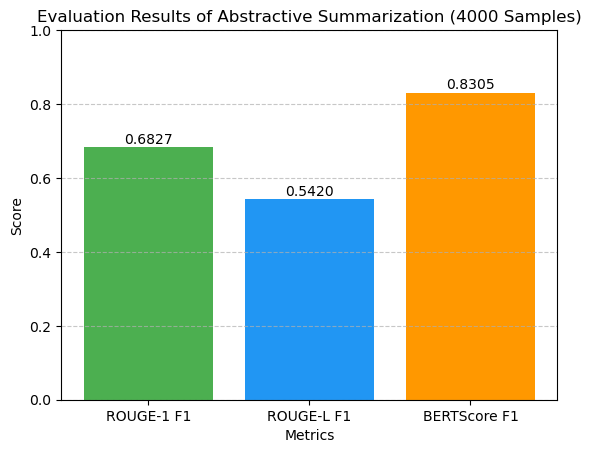

In [1]:
import matplotlib.pyplot as plt

# Dữ liệu
metrics = ['ROUGE-1 F1', 'ROUGE-L F1', 'BERTScore F1']
scores = [0.682652, 0.542045, 0.830462]

# Màu sắc (tùy chỉnh)
colors = ['#4CAF50', '#2196F3', '#FF9800']  # xanh lá, xanh dương, cam

# Tạo biểu đồ
plt.figure()
plt.bar(metrics, scores, color=colors)

# Tiêu đề và nhãn
plt.title('Evaluation Results of Abstractive Summarization (4000 Samples)')
plt.xlabel('Metrics')
plt.ylabel('Score')

# Hiển thị giá trị trên đầu cột
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=10)

# Giới hạn trục Y
plt.ylim(0, 1)

# Grid nhẹ cho đẹp
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị
plt.show()

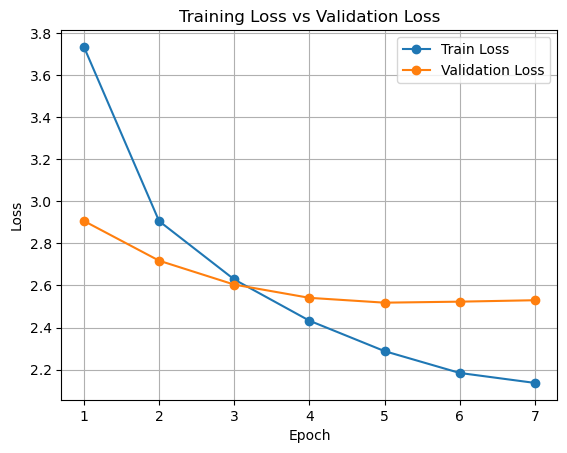

In [1]:
import matplotlib.pyplot as plt

# Dữ liệu từ bảng của bạn
epochs = [1, 2, 3, 4, 5, 6, 7]

train_loss = [3.7353, 2.9064, 2.6287, 2.4325, 2.2877, 2.1838, 2.1364]
val_loss = [2.9071, 2.7181, 2.6043, 2.5413, 2.5183, 2.5231, 2.5299]

# Vẽ biểu đồ
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

# Nhãn và tiêu đề
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')

# Hiển thị legend
plt.legend()

# Grid cho dễ nhìn
plt.grid()

# Hiển thị biểu đồ
plt.show()

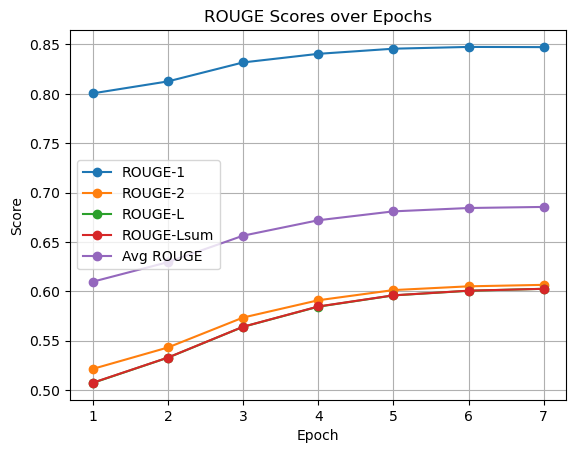

In [2]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1, 2, 3, 4, 5, 6, 7]

# Dữ liệu từ bảng của bạn
rouge1 = [0.8005, 0.8126, 0.8318, 0.8405, 0.8457, 0.8475, 0.8473]
rouge2 = [0.5215, 0.5432, 0.5735, 0.5910, 0.6013, 0.6051, 0.6066]
rougeL = [0.5073, 0.5329, 0.5641, 0.5845, 0.5959, 0.6006, 0.6026]
rougeLsum = [0.5075, 0.5330, 0.5642, 0.5847, 0.5960, 0.6007, 0.6026]
avg_rouge = [0.6098, 0.6296, 0.6564, 0.6720, 0.6810, 0.6844, 0.6855]

# Vẽ biểu đồ
plt.figure()

plt.plot(epochs, rouge1, marker='o', label='ROUGE-1')
plt.plot(epochs, rouge2, marker='o', label='ROUGE-2')
plt.plot(epochs, rougeL, marker='o', label='ROUGE-L')
plt.plot(epochs, rougeLsum, marker='o', label='ROUGE-Lsum')
plt.plot(epochs, avg_rouge, marker='o', label='Avg ROUGE')

# Nhãn
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('ROUGE Scores over Epochs')

# Hiển thị legend
plt.legend()

# Grid
plt.grid()

# Lưu ảnh (để chèn vào Word)
plt.savefig('rouge_chart.png', dpi=300)

# Hiển thị
plt.show()

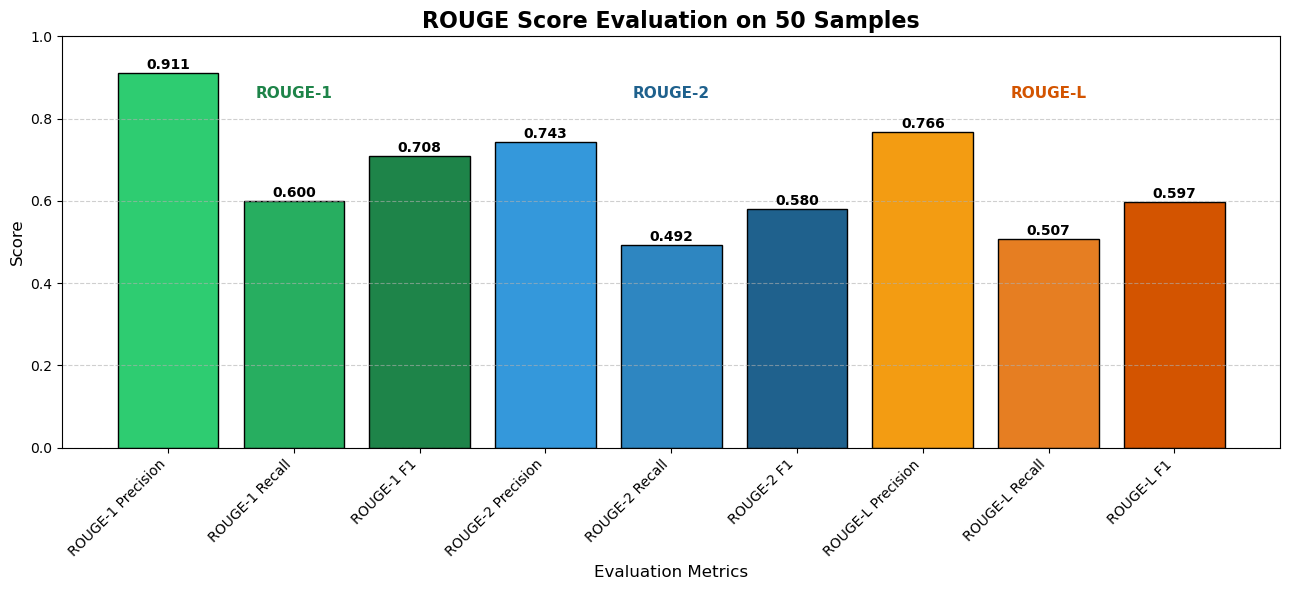

In [3]:
import matplotlib.pyplot as plt

# Dữ liệu
metrics = [
    "ROUGE-1 Precision", "ROUGE-1 Recall", "ROUGE-1 F1",
    "ROUGE-2 Precision", "ROUGE-2 Recall", "ROUGE-2 F1",
    "ROUGE-L Precision", "ROUGE-L Recall", "ROUGE-L F1"
]

values = [
    0.9115, 0.6003, 0.7081,
    0.7434, 0.4918, 0.5795,
    0.7663, 0.5068, 0.5970
]

# Màu theo từng nhóm
colors = [
    "#2ecc71", "#27ae60", "#1e8449",   # ROUGE-1 (xanh lá)
    "#3498db", "#2e86c1", "#1f618d",   # ROUGE-2 (xanh dương)
    "#f39c12", "#e67e22", "#d35400"    # ROUGE-L (cam)
]

# Vẽ biểu đồ
plt.figure(figsize=(13, 6))
bars = plt.bar(metrics, values, color=colors, edgecolor='black')

# Tiêu đề và nhãn
plt.title("ROUGE Score Evaluation on 50 Samples", fontsize=16, fontweight='bold')
plt.xlabel("Evaluation Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)

# Xoay label 45 độ
plt.xticks(rotation=45, ha='right')

# Hiển thị giá trị trên từng cột
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Thêm chú thích nhóm
plt.text(1, 0.85, "ROUGE-1", ha='center', fontsize=11, color="#1e8449", fontweight='bold')
plt.text(4, 0.85, "ROUGE-2", ha='center', fontsize=11, color="#1f618d", fontweight='bold')
plt.text(7, 0.85, "ROUGE-L", ha='center', fontsize=11, color="#d35400", fontweight='bold')

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Giới hạn trục
plt.ylim(0, 1)

# Layout đẹp
plt.tight_layout()

# Lưu ảnh chất lượng cao (để chèn Word)
plt.savefig("rouge_chart.png", dpi=300)

# Hiển thị
plt.show()

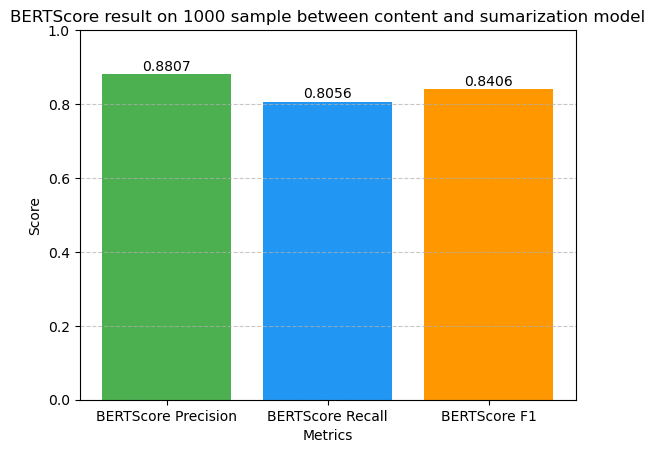

In [1]:
import matplotlib.pyplot as plt

# Dữ liệu
metrics = ['BERTScore Precision', 'BERTScore Recall', 'BERTScore F1']
scores = [0.8807, 0.8056, 0.8406]

# Màu sắc (tùy chỉnh)
colors = ['#4CAF50', '#2196F3', '#FF9800']  # xanh lá, xanh dương, cam

# Tạo biểu đồ
plt.figure()
plt.bar(metrics, scores, color=colors)

# Tiêu đề và nhãn
plt.title('BERTScore result on 1000 sample between content and sumarization model')
plt.xlabel('Metrics')
plt.ylabel('Score')

# Hiển thị giá trị trên đầu cột
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=10)

# Giới hạn trục Y
plt.ylim(0, 1)

# Grid nhẹ cho đẹp
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị
plt.show()

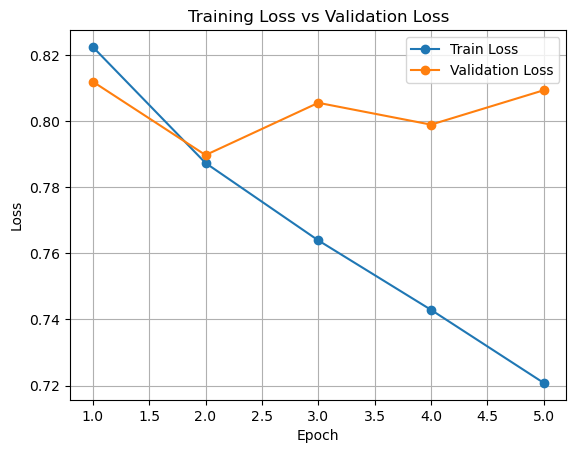

In [9]:
import matplotlib.pyplot as plt

# Dữ liệu từ bảng của bạn
epochs = [1, 2, 3, 4, 5]

train_loss = [0.8224, 0.7873, 0.7639, 0.7429, 0.7208]

val_loss = [0.8119, 0.7897, 0.8055, 0.7989, 0.8093]


# Vẽ biểu đồ
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

# Nhãn và tiêu đề
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')

# Hiển thị legend
plt.legend()

# Grid cho dễ nhìn
plt.grid()

# Hiển thị biểu đồ
plt.show()

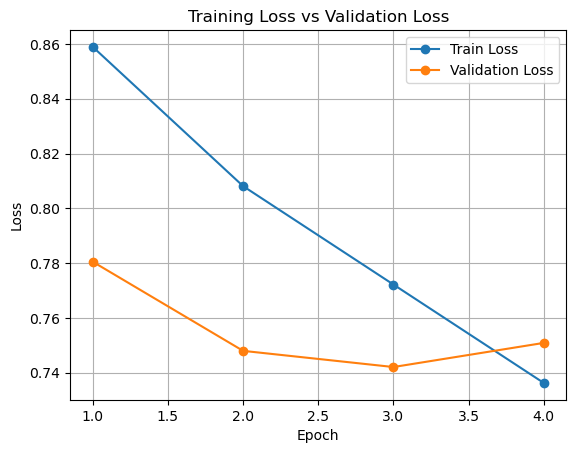

In [4]:
import matplotlib.pyplot as plt

# Dữ liệu từ bảng của bạn
epochs = [1, 2, 3, 4]

train_loss = [0.8589, 0.8081, 0.7722, 0.7363]
val_loss = [0.7805, 0.7480, 0.7421, 0.7509]

# Vẽ biểu đồ
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

# Nhãn và tiêu đề
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')

# Hiển thị legend
plt.legend()

# Grid cho dễ nhìn
plt.grid()

# Hiển thị biểu đồ
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Dữ liệu
metrics = [
    "ROUGE-1 Precision", "ROUGE-1 Recall", "ROUGE-1 F1",
    "ROUGE-2 Precision", "ROUGE-2 Recall", "ROUGE-2 F1",
    "ROUGE-L Precision", "ROUGE-L Recall", "ROUGE-L F1"
]

values = [
    0.7066, 0.7471, 0.7016,
    0.3479, 0.3570, 0.3397,
    0.3632, 0.3798, 0.3580
]

# Màu theo từng nhóm
colors = [
    "#2ecc71", "#27ae60", "#1e8449",   # ROUGE-1 (xanh lá)
    "#3498db", "#2e86c1", "#1f618d",   # ROUGE-2 (xanh dương)
    "#f39c12", "#e67e22", "#d35400"    # ROUGE-L (cam)
]

# Vẽ biểu đồ
plt.figure(figsize=(13, 6))
bars = plt.bar(metrics, values, color=colors, edgecolor='black')

# Tiêu đề và nhãn
plt.title("ROUGE Score Evaluation on 50 Samples", fontsize=16, fontweight='bold')
plt.xlabel("Evaluation Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)

# Xoay label 45 độ
plt.xticks(rotation=45, ha='right')

# Hiển thị giá trị trên từng cột
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Thêm chú thích nhóm
plt.text(1, 0.85, "ROUGE-1", ha='center', fontsize=11, color="#1e8449", fontweight='bold')
plt.text(4, 0.5, "ROUGE-2", ha='center', fontsize=11, color="#1f618d", fontweight='bold')
plt.text(7, 0.5, "ROUGE-L", ha='center', fontsize=11, color="#d35400", fontweight='bold')

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Giới hạn trục
plt.ylim(0, 1)

# Layout đẹp
plt.tight_layout()

# Lưu ảnh chất lượng cao (để chèn Word)
plt.savefig("rouge_chart.png", dpi=300)

# Hiển thị
plt.show()

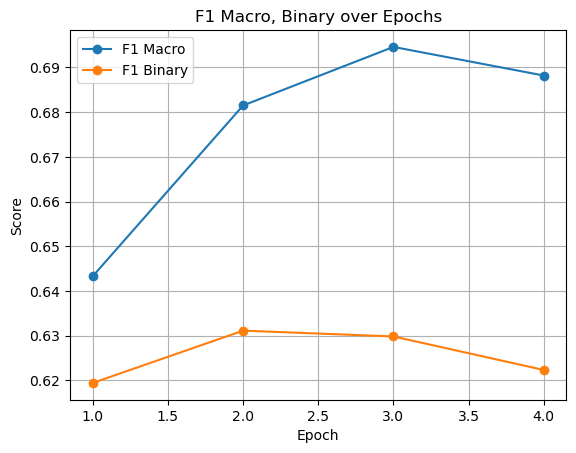

In [5]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1, 2, 3, 4]

# Dữ liệu từ bảng của bạn
f1macro = [0.6433, 0.6815, 0.6946, 0.6882]
fibinary = [0.6194, 0.6311, 0.6298, 0.6223]

# Vẽ biểu đồ
plt.figure()

plt.plot(epochs, f1macro, marker='o', label='F1 Macro')
plt.plot(epochs, fibinary, marker='o', label='F1 Binary')

# Nhãn
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('F1 Macro, Binary over Epochs')

# Hiển thị legend
plt.legend()

# Grid
plt.grid()

# Lưu ảnh (để chèn vào Word)
plt.savefig('rouge_chart.png', dpi=300)

# Hiển thị
plt.show()

In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
from vncorenlp import VnCoreNLP
from dotenv import load_dotenv
import os
load_dotenv()

llm = ChatOpenAI(
    model="gpt-4o-mini",   # rẻ + đủ mạnh tiếng Việt
    temperature=0.7,
    top_p=0.9,
    max_tokens=512
)

annotator = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

def summary_abstractive(text, grade, length):
    messages = [
        SystemMessage(
            content=f"Bạn là một hệ thống tóm tắt văn bản."
        ),
        HumanMessage(
            content=f"""
Nhiệm vụ: Tóm tắt đoạn văn bản tiếng Việt lớp {grade} dưới đây.

YÊU CẦU BẮT BUỘC:
- Viết ĐÚNG {length} câu
- Giữ đầy đủ các ý quan trọng
- Diễn đạt tự nhiên, rõ ràng.
- Câu văn rõ ràng, mạch lạc, trôi chảy
- Viết trên MỘT DÒNG
- KHÔNG thêm tiêu đề, chú thích, ký hiệu, lời dẫn hay nhận xét.

ĐOẠN VĂN:
{text}

TÓM TẮT:
"""
        )
    ]

    response = llm.invoke(messages)
    return response.content.strip()

import math
import re

SAVE_EVERY = 50
OUTPUT_PATH = "E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered_abs_sum.xlsx"
df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered.xlsx")

processed = 0

for idx, row in df.iterrows():

    existing_summary = row.get("summary_gpt", "")
    if pd.notna(existing_summary) and str(existing_summary).strip():
        continue

    content = str(row["content"]).strip()
    if not content:
        df.loc[idx, "summary_gpt"] = ""
        continue

    grade = int(row["grade"])

    # Đếm số câu
    try:
        sentences = annotator.tokenize(content)
        num_sentences = len(sentences)
    except Exception:
        df.loc[idx, "summary_gpt"] = ""
        continue

    length = max(1, math.ceil(num_sentences * 0.4))

    summary = summary_abstractive(content, grade, length)

    df.loc[idx, "summary_gpt"] = summary

    processed += 1

    if processed % SAVE_EVERY == 0:
        df.to_excel(OUTPUT_PATH, index=False)
        print(f"✅ Đã lưu tạm sau {processed} dòng")

# 👉 LƯU LẦN CUỐI
df.to_excel(OUTPUT_PATH, index=False)
print("🎉 Hoàn tất, đã lưu file cuối cùng")

C:\Users\minhv\AppData\Local\Temp\ipykernel_20676\1945255252.py:84: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Em rất kính trọng thầy Hoàng, người đã ngoài bốn mươi tuổi. Thầy có dáng cao, hơi gầy và khuôn mặt hiền từ với ánh mắt sáng. Giọng nói của thầy ấm áp, khiến chúng em chăm chú lắng nghe mỗi khi thầy giảng bài. Em mong thầy luôn khỏe mạnh để tiếp tục dạy dỗ nhiều thế hệ học sinh.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, "summary_gpt"] = summary


✅ Đã lưu tạm sau 50 dòng
✅ Đã lưu tạm sau 100 dòng
✅ Đã lưu tạm sau 150 dòng
✅ Đã lưu tạm sau 200 dòng
✅ Đã lưu tạm sau 250 dòng
✅ Đã lưu tạm sau 300 dòng
✅ Đã lưu tạm sau 350 dòng
✅ Đã lưu tạm sau 400 dòng
✅ Đã lưu tạm sau 450 dòng
✅ Đã lưu tạm sau 500 dòng
✅ Đã lưu tạm sau 550 dòng
✅ Đã lưu tạm sau 600 dòng
✅ Đã lưu tạm sau 650 dòng
✅ Đã lưu tạm sau 700 dòng
✅ Đã lưu tạm sau 750 dòng
✅ Đã lưu tạm sau 800 dòng
✅ Đã lưu tạm sau 850 dòng
✅ Đã lưu tạm sau 900 dòng
✅ Đã lưu tạm sau 950 dòng
✅ Đã lưu tạm sau 1000 dòng
✅ Đã lưu tạm sau 1050 dòng
✅ Đã lưu tạm sau 1100 dòng
✅ Đã lưu tạm sau 1150 dòng
✅ Đã lưu tạm sau 1200 dòng
✅ Đã lưu tạm sau 1250 dòng
✅ Đã lưu tạm sau 1300 dòng
✅ Đã lưu tạm sau 1350 dòng
✅ Đã lưu tạm sau 1400 dòng
✅ Đã lưu tạm sau 1450 dòng
✅ Đã lưu tạm sau 1500 dòng
✅ Đã lưu tạm sau 1550 dòng
✅ Đã lưu tạm sau 1600 dòng
✅ Đã lưu tạm sau 1650 dòng
✅ Đã lưu tạm sau 1700 dòng
✅ Đã lưu tạm sau 1750 dòng
✅ Đã lưu tạm sau 1800 dòng
✅ Đã lưu tạm sau 1850 dòng
✅ Đã lưu tạm sau 1900

In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from vncorenlp import VnCoreNLP
import pandas as pd
import re
import os
processed = 0
SAVE_EVERY = 50
llm = ChatOllama(model="llama3.2")

def summary_abstractive(text, grade, length):
    prompt = [
        SystemMessage(content=f"Bạn là một hệ thống tóm tắt văn bản."),
        HumanMessage(content=f"""
        Nhiệm vụ: Tóm tắt đoạn văn bản tiếng Việt lớp {grade} dưới đây.

YÊU CẦU BẮT BUỘC:
- Viết ĐÚNG {length} câu
- Giữ đầy đủ các ý quan trọng
- Diễn đạt tự nhiên, rõ ràng.
- Câu văn rõ ràng, mạch lạc, trôi chảy
- Viết trên MỘT DÒNG
- KHÔNG thêm tiêu đề, chú thích, ký hiệu, lời dẫn hay nhận xét.

ĐOẠN VĂN:
{text}

KẾT QUẢ:
""")
    ]
    response = llm(prompt)
    return response.content.strip()

data = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered.xlsx")
df = data[650:].copy()
annotator = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

for idx, row in df.iterrows():
    if pd.isna(row["summary"]) or row["summary"] == "":
        content = str(row["content"])
        grade = int(row["grade"])
        sentences = annotator.tokenize(content)
        num_sentences = len(sentences)
        length = max(1, math.ceil(num_sentences * 0.4))
        summary_result = summary_abstractive(content, grade, length)
        df.loc[idx, "summary"] = summary_result
        processed += 1
        if processed % SAVE_EVERY == 0:
            df.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_filtered_sum_llama2.xlsx", index=False)
            print(f"✅ Đã lưu tạm sau {processed} dòng")

df.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_filtered_sum_llama.xlsx", index=False)

C:\Users\minhv\AppData\Local\Temp\ipykernel_20676\1220354465.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Thầy Hoàng là một giáo viên có uy tín và kính trọng trong mắt em. Thầy đã ngoài 40 tuổi nhưng vẫn giữ được vẻ thông minh và ánh mắt sáng. Giọng nói của thầy ấm áp và truyền cảm, khiến em luôn chăm chú lắng nghe khi thầy giảng bài. Em mong thầy luôn khỏe mạnh để tiếp tục dạy dỗ nhiều thế hệ học sinh trong tương lai.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, "summary"] = summary_result


✅ Đã lưu tạm sau 50 dòng
✅ Đã lưu tạm sau 100 dòng
✅ Đã lưu tạm sau 150 dòng
✅ Đã lưu tạm sau 200 dòng
✅ Đã lưu tạm sau 250 dòng
✅ Đã lưu tạm sau 300 dòng
✅ Đã lưu tạm sau 350 dòng
✅ Đã lưu tạm sau 400 dòng
✅ Đã lưu tạm sau 450 dòng
✅ Đã lưu tạm sau 500 dòng
✅ Đã lưu tạm sau 550 dòng
✅ Đã lưu tạm sau 600 dòng
✅ Đã lưu tạm sau 650 dòng


KeyboardInterrupt: 

In [9]:
import pandas as pd 

df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\ex\datatest_main_score.xlsx")

dff = df.describe()

dfff1 = dff[["bertscore_bertsum", "bertscore_lead_5", "bertscore_textrank", "bertscore_lexrank", "bertscore_mymodel"]]
dfff2 = dff[["rouge1_bertsum", "rouge1_lead_5", "rouge1_textrank", "rouge1_lexrank", "rouge1_mymodel"]]
dfff3 = dff[["rouge2_bertsum", "rouge2_lead_5", "rouge2_textrank", "rouge2_lexrank", "rouge2_mymodel"]]
dfff4 = dff[["rougel_bertsum", "rougel_lead_5", "rougel_textrank", "rougel_lexrank", "rougel_mymodel"]]
dfff1

,bertscore_bertsum,bertscore_lead_5,bertscore_textrank,bertscore_lexrank,bertscore_mymodel
count,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000
mean,0.753988,0.729410,0.793477,0.776265,0.714867
std,0.079706,0.064637,0.075099,0.077798,0.082851
min,0.400037,0.486724,0.432494,0.393420,0.379114
25%,0.706256,0.688236,0.748248,0.730333,0.664915
50%,0.758819,0.729136,0.796976,0.781948,0.719555
75%,0.806927,0.771998,0.845070,0.829404,0.769179
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
dfff2

,rouge1_bertsum,rouge1_lead_5,rouge1_textrank,rouge1_lexrank,rouge1_mymodel
count,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000
mean,0.809965,0.779095,0.829475,0.818821,0.768962
std,0.070857,0.064445,0.067185,0.069799,0.078555
min,0.375000,0.390805,0.379747,0.333333,0.350000
25%,0.775484,0.744778,0.798283,0.786815,0.729167
50%,0.823140,0.789809,0.839844,0.830631,0.783088
75%,0.858469,0.824688,0.873848,0.865672,0.822656
max,1.000000,0.991822,1.000000,1.000000,1.000000


In [11]:
dfff3

,rouge2_bertsum,rouge2_lead_5,rouge2_textrank,rouge2_lexrank,rouge2_mymodel
count,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000
mean,0.589083,0.524564,0.644928,0.615307,0.514439
std,0.127175,0.099407,0.124491,0.127031,0.128839
min,0.044944,0.167742,0.025974,0.000000,0.019802
25%,0.515527,0.462132,0.571908,0.540541,0.438356
50%,0.600000,0.526923,0.655238,0.626866,0.522831
75%,0.675121,0.591813,0.728801,0.701179,0.599327
max,1.000000,0.988182,1.000000,1.000000,1.000000


In [12]:
dfff4

,rougel_bertsum,rougel_lead_5,rougel_textrank,rougel_lexrank,rougel_mymodel
count,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000
mean,0.603622,0.520340,0.656122,0.627736,0.530960
std,0.112746,0.085568,0.114770,0.113532,0.111462
min,0.225000,0.252874,0.278481,0.205128,0.222222
25%,0.527599,0.461538,0.580406,0.553347,0.452482
50%,0.603448,0.513238,0.658065,0.628788,0.528736
75%,0.679790,0.572494,0.734141,0.704089,0.605012
max,1.000000,0.991822,1.000000,1.000000,1.000000


In [ ]:
import pandas as pd
import numpy as np
import unicodedata
from rouge_score import rouge_scorer
from bert_score import BERTScorer
from transformers import AutoTokenizer
from underthesea import word_tokenize

# =========================
# 1. CHUẨN HÓA VĂN BẢN
# =========================
def normalize_text(text):
    """
    Chuẩn hóa Unicode NFC cho tiếng Việt.
    Tiếng Việt có thể được encode theo 2 cách:
      - NFD: "ộ" = "o" + combining diacritics (nhiều ký tự)
      - NFC: "ộ" = 1 ký tự duy nhất
    Nếu không chuẩn hóa, so sánh chuỗi sẽ bị sai dù nhìn giống nhau.
    """
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFC", text)
    # Bỏ khoảng trắng thừa (đầu/cuối và giữa các từ)
    text = " ".join(text.split())
    return text.strip()


# =========================
# 2. ROUGE (có word segmentation tiếng Việt)
# =========================
def segment_vi(text):
    """
    Tách từ tiếng Việt bằng underthesea.
    Ví dụ: "học sinh giỏi" -> "học_sinh giỏi"
    Quan trọng vì ROUGE tính n-gram dựa trên từ,
    nếu không segment thì "học sinh" bị tính là 2 unigram thay vì 1 bigram.
    """
    try:
        return word_tokenize(text, format="text")
    except Exception:
        # Fallback: trả về nguyên bản nếu segment thất bại
        return text


def compute_rouge(candidate, reference):
    """
    Tính ROUGE-1, ROUGE-2, ROUGE-L F1.
    Lưu ý: normalize + segment TRƯỚC khi đưa vào scorer.
    """
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=False   # Tiếng Việt không dùng stemmer
    )
    # Chuẩn hóa Unicode trước
    ref_norm  = normalize_text(reference)
    cand_norm = normalize_text(candidate)

    # Tách từ tiếng Việt
    ref_seg  = segment_vi(ref_norm)
    cand_seg = segment_vi(cand_norm)

    # scorer.score(target=reference, prediction=candidate)
    scores = scorer.score(ref_seg, cand_seg)
    return (
        scores['rouge1'].fmeasure,
        scores['rouge2'].fmeasure,
        scores['rougeL'].fmeasure
    )


# =========================
# 3. TRUNCATE cho BERTScore
# =========================
def safe_truncate(text, tokenizer, max_tokens=250):
    """
    Truncate văn bản về max_tokens token của PhoBERT.
    PhoBERT dùng BPE nên cần tokenizer riêng, không cắt thô theo ký tự.
    """
    text = normalize_text(text)
    if not text:
        return ""

    ids = tokenizer.encode(
        text,
        truncation=True,
        max_length=max_tokens,
        add_special_tokens=True
    )
    decoded = tokenizer.decode(ids, skip_special_tokens=True)

    # PhoBERT có thể để lại artifact "▁" (sentencepiece underscore)
    decoded = decoded.replace("▁", " ").strip()
    decoded = " ".join(decoded.split())  # chuẩn hóa lại khoảng trắng
    return decoded


# =========================
# 4. BERTScore
# =========================
def compute_bertscore(candidate, reference, scorer, tokenizer):
    """
    Tính BERTScore F1 dùng PhoBERT.
    Truncate về 250 token để tránh lỗi vượt max_length của PhoBERT (256 tokens).
    """
    cand = safe_truncate(candidate, tokenizer)
    ref  = safe_truncate(reference,  tokenizer)

    # Fallback an toàn: lấy câu đầu tiên thay vì cắt thô [:100]
    if not cand.strip():
        cand = candidate.split(".")[0].strip() or normalize_text(candidate)[:200]
    if not ref.strip():
        ref  = reference.split(".")[0].strip()  or normalize_text(reference)[:200]

    _, _, F1 = scorer.score([cand], [ref])
    return F1.item()


# =========================
# 5. MODEL SETUP
# =========================
PHOBERT_NAME = "vinai/phobert-base"

tokenizer = AutoTokenizer.from_pretrained(PHOBERT_NAME, use_fast=False)

bert_scorer = BERTScorer(
    model_type=PHOBERT_NAME,
    num_layers=12,          # Dùng layer cuối cùng của phobert-base (12 layers)
    lang="vi",
    device="cpu",
    batch_size=8,
    rescale_with_baseline=False,  # Baseline cho tiếng Việt + PhoBERT chưa được publish
)


# =========================
# 6. LOAD DATA
# =========================
INPUT_PATH  = r"/kaggle/working/data-test/datatest_main.xlsx"
OUTPUT_PATH = r"/kaggle/working/data-test/datatest_main_score.xlsx"

df = pd.read_excel(INPUT_PATH)


# =========================
# 7. CONFIG COLUMNS
# =========================
REF_COL = "summary_ref"

CANDIDATE_COLS = [
    "summary_lead_5",
    "summary_textrank",
    "summary_lexrank",
    "summary_bertsum",
    "summary_mymodel"
]

NAME_MAP = {
    "summary_lead_5":    "lead_5",
    "summary_textrank":  "textrank",
    "summary_lexrank":   "lexrank",
    "summary_bertsum":   "bertsum",
    "summary_mymodel":   "mymodel"
}


# =========================
# 8. TẠO CỘT METRIC (nếu chưa có)
# =========================
for col in CANDIDATE_COLS:
    name = NAME_MAP[col]
    for metric in ["rouge1", "rouge2", "rougel", "bertscore"]:
        metric_col = f"{metric}_{name}"
        if metric_col not in df.columns:
            df[metric_col] = np.nan


# =========================
# 9. EVALUATION LOOP
# =========================
print("[INFO] Start evaluating...")

try:
    for i, (idx, row) in enumerate(df.iterrows()):
        reference = row.get(REF_COL, "")

        # Bỏ qua nếu reference rỗng hoặc không phải string
        if not isinstance(reference, str) or not normalize_text(reference):
            continue

        for col in CANDIDATE_COLS:
            candidate = row.get(col, "")

            # Bỏ qua nếu candidate rỗng
            if not isinstance(candidate, str) or not normalize_text(candidate):
                continue

            try:
                r1, r2, rl = compute_rouge(candidate, reference)
                bs = compute_bertscore(candidate, reference, bert_scorer, tokenizer)

                name = NAME_MAP[col]
                df.at[idx, f"rouge1_{name}"]    = r1
                df.at[idx, f"rouge2_{name}"]    = r2
                df.at[idx, f"rougel_{name}"]    = rl
                df.at[idx, f"bertscore_{name}"] = bs

            except Exception as e:
                print(f"⚠️  Error row {idx}, col {col}: {e}")
                continue

        # Lưu checkpoint mỗi 50 dòng
        if i % 50 == 0:
            df.to_excel(OUTPUT_PATH, index=False)
            print(f"  [{i}/{len(df)}] checkpoint saved")

finally:
    # Đảm bảo luôn lưu file dù có crash giữa chừng
    df.to_excel(OUTPUT_PATH, index=False)
    print(f"✅ DONE — saved to {OUTPUT_PATH}")

In [ ]:
!cp -r /kaggle/input/datasets/biubiu2309/data-test /kaggle/working/
%cd /kaggle/working/data-test
!ls
!pip install pandas numpy
!pip install rouge-score
!pip install bert-score
!pip install transformers torch
!pip install openpyxl
!pip install underthesea


import pandas as pd
import numpy as np
import unicodedata
from rouge_score import rouge_scorer
from bert_score import BERTScorer
from transformers import AutoTokenizer
from underthesea import word_tokenize

# =========================
# 1. CHUẨN HÓA VĂN BẢN
# =========================
def normalize_text(text):
    """
    Chuẩn hóa Unicode NFC cho tiếng Việt.
    Tiếng Việt có thể được encode theo 2 cách:
      - NFD: "ộ" = "o" + combining diacritics (nhiều ký tự)
      - NFC: "ộ" = 1 ký tự duy nhất
    Nếu không chuẩn hóa, so sánh chuỗi sẽ bị sai dù nhìn giống nhau.
    """
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFC", text)
    # Bỏ khoảng trắng thừa (đầu/cuối và giữa các từ)
    text = " ".join(text.split())
    return text.strip()


# =========================
# 2. ROUGE (có word segmentation tiếng Việt)
# =========================
def segment_vi(text):
    """
    Tách từ tiếng Việt bằng underthesea.
    Ví dụ: "học sinh giỏi" -> "học_sinh giỏi"
    Quan trọng vì ROUGE tính n-gram dựa trên từ,
    nếu không segment thì "học sinh" bị tính là 2 unigram thay vì 1 bigram.
    """
    try:
        return word_tokenize(text, format="text")
    except Exception:
        # Fallback: trả về nguyên bản nếu segment thất bại
        return text


def compute_rouge(candidate, reference):
    """
    Tính ROUGE-1, ROUGE-2, ROUGE-L F1.
    Lưu ý: normalize + segment TRƯỚC khi đưa vào scorer.
    """
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=False   # Tiếng Việt không dùng stemmer
    )
    # Chuẩn hóa Unicode trước
    ref_norm  = normalize_text(reference)
    cand_norm = normalize_text(candidate)

    # Tách từ tiếng Việt
    ref_seg  = segment_vi(ref_norm)
    cand_seg = segment_vi(cand_norm)

    # scorer.score(target=reference, prediction=candidate)
    scores = scorer.score(ref_seg, cand_seg)
    return (
        scores['rouge1'].fmeasure,
        scores['rouge2'].fmeasure,
        scores['rougeL'].fmeasure
    )


# =========================
# 3. TRUNCATE cho BERTScore
# =========================
def safe_truncate(text, tokenizer, max_tokens=250):
    """
    Truncate văn bản về max_tokens token của PhoBERT.
    PhoBERT dùng BPE nên cần tokenizer riêng, không cắt thô theo ký tự.
    """
    text = normalize_text(text)
    if not text:
        return ""

    ids = tokenizer.encode(
        text,
        truncation=True,
        max_length=max_tokens,
        add_special_tokens=True
    )
    decoded = tokenizer.decode(ids, skip_special_tokens=True)

    # PhoBERT có thể để lại artifact "▁" (sentencepiece underscore)
    decoded = decoded.replace("▁", " ").strip()
    decoded = " ".join(decoded.split())  # chuẩn hóa lại khoảng trắng
    return decoded


# =========================
# 4. BERTScore
# =========================
def compute_bertscore(candidate, reference, scorer, tokenizer):
    """
    Tính BERTScore F1 dùng PhoBERT.
    Truncate về 250 token để tránh lỗi vượt max_length của PhoBERT (256 tokens).
    """
    cand = safe_truncate(candidate, tokenizer)
    ref  = safe_truncate(reference,  tokenizer)

    # Fallback an toàn: lấy câu đầu tiên thay vì cắt thô [:100]
    if not cand.strip():
        cand = candidate.split(".")[0].strip() or normalize_text(candidate)[:200]
    if not ref.strip():
        ref  = reference.split(".")[0].strip()  or normalize_text(reference)[:200]

    _, _, F1 = scorer.score([cand], [ref])
    return F1.item()


# =========================
# 5. MODEL SETUP
# =========================
PHOBERT_NAME = "vinai/phobert-base"

tokenizer = AutoTokenizer.from_pretrained(PHOBERT_NAME, use_fast=False)

bert_scorer = BERTScorer(
    model_type=PHOBERT_NAME,
    num_layers=12,          # Dùng layer cuối cùng của phobert-base (12 layers)
    lang="vi",
    device="cpu",
    batch_size=8,
    rescale_with_baseline=False,  # Baseline cho tiếng Việt + PhoBERT chưa được publish
)


# =========================
# 6. LOAD DATA
# =========================
INPUT_PATH  = r"/kaggle/working/data-test/datatest_main.xlsx"
OUTPUT_PATH = r"/kaggle/working/data-test/datatest_main_score.xlsx"

df = pd.read_excel(INPUT_PATH)


# =========================
# 7. CONFIG COLUMNS
# =========================
REF_COL = "summary_ref"

CANDIDATE_COLS = [
    "summary_qwen",
    "summary_llama",
    "summary_gpt",
    "summary_mymodel"
]

NAME_MAP = {
    "summary_qwen":    "qwen",
    "summary_llama":  "llama",
    "summary_gpt":   "gpt",
    "summary_mymodel":   "mymodel"
}


# =========================
# 8. TẠO CỘT METRIC (nếu chưa có)
# =========================
for col in CANDIDATE_COLS:
    name = NAME_MAP[col]
    for metric in ["rouge1", "rouge2", "rougel", "bertscore"]:
        metric_col = f"{metric}_{name}"
        if metric_col not in df.columns:
            df[metric_col] = np.nan


# =========================
# 9. EVALUATION LOOP
# =========================
print("[INFO] Start evaluating...")

try:
    for i, (idx, row) in enumerate(df.iterrows()):
        reference = row.get(REF_COL, "")

        # Bỏ qua nếu reference rỗng hoặc không phải string
        if not isinstance(reference, str) or not normalize_text(reference):
            continue

        for col in CANDIDATE_COLS:
            candidate = row.get(col, "")

            # Bỏ qua nếu candidate rỗng
            if not isinstance(candidate, str) or not normalize_text(candidate):
                continue

            try:
                r1, r2, rl = compute_rouge(candidate, reference)
                bs = compute_bertscore(candidate, reference, bert_scorer, tokenizer)

                name = NAME_MAP[col]
                df.at[idx, f"rouge1_{name}"]    = r1
                df.at[idx, f"rouge2_{name}"]    = r2
                df.at[idx, f"rougel_{name}"]    = rl
                df.at[idx, f"bertscore_{name}"] = bs

            except Exception as e:
                print(f"⚠️  Error row {idx}, col {col}: {e}")
                continue

        # Lưu checkpoint mỗi 50 dòng
        if i % 50 == 0:
            df.to_excel(OUTPUT_PATH, index=False)
            print(f"  [{i}/{len(df)}] checkpoint saved")

finally:
    # Đảm bảo luôn lưu file dù có crash giữa chừng
    df.to_excel(OUTPUT_PATH, index=False)
    print(f"✅ DONE — saved to {OUTPUT_PATH}")

print(df[["bertscore_bertsum", "bertscore_lead_5", "bertscore_textrank", "bertscore_lexrank", "bertscore_mymodel"]].mean())
print(df[["rouge1_bertsum", "rouge1_lead_5", "rouge1_textrank", "rouge1_lexrank", "rouge1_mymodel"]].mean())
print(df[["rouge2_bertsum", "rouge2_lead_5", "rouge2_textrank", "rouge2_lexrank", "rouge2_mymodel"]].mean())
print(df[["rougel_bertsum", "rougel_lead_5", "rougel_textrank", "rougel_lexrank", "rougel_mymodel"]].mean())

In [ ]:
# --- Đặc trưng ngôn ngữ cho cột summary (theo Evaluation_Agent + MakeTextEasy) ---
import re
from pathlib import Path

import pandas as pd
from underthesea import word_tokenize

# CWD khi chạy notebook thường là thư mục chứa file .ipynb
DATASETS = (Path(".") / "../../../datasets").resolve()
GRADE_VOCAB_DIR = DATASETS / "grade_vocab"
HANVIET_XLSX = DATASETS / "hanviet_vocab" / "vocab_mapped.xlsx"

INPUT_EXCEL = DATASETS / "datatest" / "abs" / "datatest_main_score.xlsx"
OUTPUT_EXCEL = DATASETS / "datatest" / "abs" / "datatest_main_score_dif_ref.xlsx"
SUMMARY_COL = "summary_ref"
GRADE_COL = "grade"  # nếu không có cột này, dùng DEFAULT_GRADE
DEFAULT_GRADE = 5
LONG_SENTENCE_THRESHOLD = 15
MIN_WORD_CHAR_PATTERN = re.compile(r"[0-9A-Za-zÀ-ỹ_]")


def preprocess_vi(text: str) -> str:
    text = (text or "").strip().replace("\n", " ")
    return word_tokenize(text, format="text")


def _normalize_token(token: str) -> str:
    token = token.strip().lower()
    token = re.sub(r"^[^\wÀ-ỹ]+|[^\wÀ-ỹ]+$", "", token, flags=re.UNICODE)
    return token


def _valid_norm_tokens_from_summary(summary: str) -> list[str]:
    if not isinstance(summary, str) or not summary.strip():
        return []
    toks = preprocess_vi(summary).split()
    out: list[str] = []
    for tok in toks:
        n = _normalize_token(tok)
        if not n or not MIN_WORD_CHAR_PATTERN.search(n):
            continue
        out.append(n)
    return out


def load_hanviet_vocab(path: Path = HANVIET_XLSX) -> set[str]:
    if not path.exists():
        return set()
    dfv = pd.read_excel(path, dtype=str)
    if "ChuHanViet" not in dfv.columns:
        return set()
    s: set[str] = set()
    for w in dfv["ChuHanViet"].dropna().astype(str):
        n = _normalize_token(w)
        if n:
            s.add(n)
    return s


def load_grade_vocab_single(grade: int, vocab_dir: Path = GRADE_VOCAB_DIR) -> set[str]:
    g = int(max(1, min(5, grade)))
    p = vocab_dir / f"grade_{g}.txt"
    if not p.exists():
        return set()
    return {_normalize_token(line) for line in p.read_text(encoding="utf-8").splitlines() if _normalize_token(line)}


def build_grade_vocab_map(vocab_dir: Path = GRADE_VOCAB_DIR) -> dict[int, set[str]]:
    return {g: load_grade_vocab_single(g, vocab_dir) for g in range(1, 6)}


def infer_word_grade(word_norm: str, grade_vocab_map: dict[int, set[str]]) -> int:
    for g in range(1, 6):
        if word_norm in grade_vocab_map[g]:
            return g
    return 99


def compute_difficulty_surface(summary: str) -> dict:
    """Câu / độ dài: giống Evaluation_Agent._compute_difficulty_features (không gồm rare/unknown/grade)."""
    raw = (summary or "").strip()
    if not raw:
        return {
            "total_words": 0,
            "unique_words": 0,
            "num_sentences": 1,
            "avg_sentence_length": 0.0,
            "long_sentence_ratio": 0.0,
            "avg_word_length": 0.0,
            "words_per_sentence": 0.0,
        }

    sentence_splits = re.split(r"[.!?]+", raw)
    sentences = [s.strip() for s in sentence_splits if s.strip()]
    num_sentences = max(1, len(sentences))

    tokens = preprocess_vi(raw).split()
    total_words = len(tokens)
    unique_words = len(set(tokens)) if total_words else 0

    sentence_lengths: list[int] = []
    for sent in sentences:
        sentence_lengths.append(len(preprocess_vi(sent).split()))

    if sentence_lengths:
        avg_sentence_length = sum(sentence_lengths) / len(sentence_lengths)
        long_count = sum(1 for ln in sentence_lengths if ln >= LONG_SENTENCE_THRESHOLD)
        long_sentence_ratio = long_count / len(sentence_lengths)
    else:
        avg_sentence_length = 0.0
        long_sentence_ratio = 0.0

    word_lengths = [len(w) for w in tokens] if tokens else []
    avg_word_length = (sum(word_lengths) / len(word_lengths)) if word_lengths else 0.0
    words_per_sentence = (total_words / num_sentences) if num_sentences else 0.0

    return {
        "total_words": total_words,
        "unique_words": unique_words,
        "num_sentences": num_sentences,
        "avg_sentence_length": float(avg_sentence_length),
        "long_sentence_ratio": float(long_sentence_ratio),
        "avg_word_length": float(avg_word_length),
        "words_per_sentence": float(words_per_sentence),
    }


def compute_lexical_grade_features(
    summary: str,
    target_grade: int,
    grade_vocab_map: dict[int, set[str]],
    hanviet_vocab: set[str],
) -> dict:
    """rare / unknown / avg_word_grade / Hán Việt: theo logic MakeTextEasy (identify_target_tokens + infer_word_grade)."""
    toks = _valid_norm_tokens_from_summary(summary)
    n_tok = len(toks)
    if n_tok == 0:
        return {
            "rare_word_ratio": 0.0,
            "unknown_word_ratio": 0.0,
            "avg_word_grade": 0.0,
            "hanviet_word_count": 0,
        }

    tg = int(max(1, min(5, target_grade)))
    vocab_target = grade_vocab_map.get(tg, set())
    vocab_union = set().union(*(grade_vocab_map[g] for g in range(1, 6)))

    rare = sum(1 for t in toks if t not in vocab_target)
    unknown = sum(1 for t in toks if t not in vocab_union)
    grades_known = [infer_word_grade(t, grade_vocab_map) for t in toks]
    grades_f = [g for g in grades_known if g != 99]
    avg_word_grade = (sum(grades_f) / len(grades_f)) if grades_f else 0.0
    hanviet_word_count = sum(1 for t in toks if t in hanviet_vocab)

    return {
        "rare_word_ratio": rare / n_tok,
        "unknown_word_ratio": unknown / n_tok,
        "avg_word_grade": float(avg_word_grade),
        "hanviet_word_count": int(hanviet_word_count),
    }


def summary_linguistic_feature_row(summary, grade_val, grade_vocab_map, hanviet_vocab):
    try:
        g = int(grade_val)
    except Exception:
        g = DEFAULT_GRADE
    surf = compute_difficulty_surface(summary if isinstance(summary, str) else "")
    lex = compute_lexical_grade_features(summary, g, grade_vocab_map, hanviet_vocab)
    return {**surf, **lex}


# ---- Chạy: đọc Excel, thêm cột, ghi file ----
_grade_map = build_grade_vocab_map()
_hanviet = load_hanviet_vocab()

_df = pd.read_excel(INPUT_EXCEL)
if SUMMARY_COL not in _df.columns:
    raise KeyError(f"Thiếu cột {SUMMARY_COL!r} trong {INPUT_EXCEL}")

def _row_grade(row):
    if GRADE_COL in _df.columns and pd.notna(row.get(GRADE_COL)):
        return row[GRADE_COL]
    return DEFAULT_GRADE

_feat_cols = [
    "total_words",
    "unique_words",
    "rare_word_ratio",
    "unknown_word_ratio",
    "avg_word_grade",
    "num_sentences",
    "avg_sentence_length",
    "long_sentence_ratio",
    "avg_word_length",
    "words_per_sentence",
    "hanviet_word_count",
]

_rows = []
for _, row in _df.iterrows():
    d = summary_linguistic_feature_row(row[SUMMARY_COL], _row_grade(row), _grade_map, _hanviet)
    _rows.append(d)

_feat_df = pd.DataFrame(_rows)
for c in _feat_cols:
    _df[c] = _feat_df[c]

_df.to_excel(OUTPUT_EXCEL, index=False)
print("Đã ghi:", OUTPUT_EXCEL)
print(_df[_feat_cols].head())

Đã ghi: E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_ref.xlsx
   total_words  unique_words  rare_word_ratio  unknown_word_ratio  \
0           54            43         0.083333            0.041667   
1           60            47         0.113208            0.018868   
2           58            42         0.115385            0.019231   
3           65            53         0.105263            0.035088   
4           55            40         0.085106            0.042553   

   avg_word_grade  num_sentences  avg_sentence_length  long_sentence_ratio  \
0        1.173913              4                12.50                 0.25   
1        1.326923              5                11.00                 0.20   
2        1.313725              5                10.60                 0.20   
3        1.236364              5                12.00                 0.20   
4        1.200000              4                12.75                 0.00   

   avg_word

In [7]:
df1 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_ref.xlsx")
df2 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_qwen.xlsx")
df3 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_llama.xlsx")
df4 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_gpt.xlsx")
df5 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_mymodel.xlsx")

print(df1[["total_words", "unique_words", "rare_word_ratio", "unknown_word_ratio", "avg_word_grade", "num_sentences", "avg_sentence_length", "long_sentence_ratio", "avg_word_length", "words_per_sentence", "hanviet_word_count"]].mean())
print(df2[["total_words", "unique_words", "rare_word_ratio", "unknown_word_ratio", "avg_word_grade", "num_sentences", "avg_sentence_length", "long_sentence_ratio", "avg_word_length", "words_per_sentence", "hanviet_word_count"]].mean())
print(df3[["total_words", "unique_words", "rare_word_ratio", "unknown_word_ratio", "avg_word_grade", "num_sentences", "avg_sentence_length", "long_sentence_ratio", "avg_word_length", "words_per_sentence", "hanviet_word_count"]].mean())
print(df4[["total_words", "unique_words", "rare_word_ratio", "unknown_word_ratio", "avg_word_grade", "num_sentences", "avg_sentence_length", "long_sentence_ratio", "avg_word_length", "words_per_sentence", "hanviet_word_count"]].mean())
print(df5[["total_words", "unique_words", "rare_word_ratio", "unknown_word_ratio", "avg_word_grade", "num_sentences", "avg_sentence_length", "long_sentence_ratio", "avg_word_length", "words_per_sentence", "hanviet_word_count"]].mean())


total_words            152.205906
unique_words            98.591201
rare_word_ratio          0.057303
unknown_word_ratio       0.050380
avg_word_grade           1.158354
num_sentences            9.995781
avg_sentence_length     14.480438
long_sentence_ratio      0.457896
avg_word_length          3.728066
words_per_sentence      15.383870
hanviet_word_count      25.921254
dtype: float64
total_words            102.828244
unique_words            69.909602
rare_word_ratio          0.078452
unknown_word_ratio       0.067262
avg_word_grade           1.210659
num_sentences            7.374448
avg_sentence_length     14.107536
long_sentence_ratio      0.392411
avg_word_length          3.759996
words_per_sentence      14.873674
hanviet_word_count      17.041583
dtype: float64
total_words            89.543391
unique_words           59.771997
rare_word_ratio         0.065684
unknown_word_ratio      0.056923
avg_word_grade          1.186962
num_sentences           6.247288
avg_sentence_length    1

In [3]:
import pandas as pd

df1 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_ref.xlsx")
df2 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_qwen.xlsx")
df3 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_llama.xlsx")
df4 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_gpt.xlsx")
df5 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_mymodel.xlsx")

cols = ["total_words", "unique_words", "rare_word_ratio", "unknown_word_ratio",
        "avg_word_grade", "num_sentences", "avg_sentence_length",
        "long_sentence_ratio", "avg_word_length", "words_per_sentence",
        "hanviet_word_count"]
print(df1.loc[df1["grade"] == 2, cols].mean())
print(df1.loc[df1["grade"] == 3, cols].mean())
print(df1.loc[df1["grade"] == 4, cols].mean())
print(df1.loc[df1["grade"] == 5, cols].mean())

print(df2.loc[df2["grade"] == 2, cols].mean())
print(df2.loc[df2["grade"] == 3, cols].mean())
print(df2.loc[df2["grade"] == 4, cols].mean())
print(df2.loc[df2["grade"] == 5, cols].mean())

print(df3.loc[df3["grade"] == 2, cols].mean())
print(df3.loc[df3["grade"] == 3, cols].mean())
print(df3.loc[df3["grade"] == 4, cols].mean())
print(df3.loc[df3["grade"] == 5, cols].mean())

print(df4.loc[df4["grade"] == 2, cols].mean())
print(df4.loc[df4["grade"] == 3, cols].mean())
print(df4.loc[df4["grade"] == 4, cols].mean())
print(df4.loc[df4["grade"] == 5, cols].mean())

print(df5.loc[df5["grade"] == 2, cols].mean())
print(df5.loc[df5["grade"] == 3, cols].mean())
print(df5.loc[df5["grade"] == 4, cols].mean())
print(df5.loc[df5["grade"] == 5, cols].mean())

total_words            75.787970
unique_words           54.711278
rare_word_ratio         0.085096
unknown_word_ratio      0.055259
avg_word_grade          1.135214
num_sentences           5.523308
avg_sentence_length    12.849298
long_sentence_ratio     0.303357
avg_word_length         3.604945
words_per_sentence     13.741473
hanviet_word_count     12.309774
dtype: float64
total_words            127.687302
unique_words            85.277778
rare_word_ratio          0.067121
unknown_word_ratio       0.052131
avg_word_grade           1.148278
num_sentences            8.611111
avg_sentence_length     14.235130
long_sentence_ratio      0.424089
avg_word_length          3.708418
words_per_sentence      15.137915
hanviet_word_count      21.682540
dtype: float64
total_words            158.165169
unique_words           101.626123
rare_word_ratio          0.055348
unknown_word_ratio       0.051769
avg_word_grade           1.150125
num_sentences           10.156876
avg_sentence_length     14.93

In [7]:
import matplotlib.pyplot as plt
import numpy as np

model_names = {"df1": "Reference", "df2": "Qwen", "df3": "Llama", "df4": "GPT", "df5": "OurModel"}
dfs = {"df1": df1, "df2": df2, "df3": df3, "df4": df4, "df5": df5}
grades = [2, 3, 4, 5]

records = []
for key, df in dfs.items():
    for g in grades:
        m = df.loc[df["grade"] == g, cols].mean()
        m["model"] = model_names[key]
        m["grade"] = g
        records.append(m)
summary = pd.DataFrame(records)
summary

,total_words,unique_words,rare_word_ratio,unknown_word_ratio,avg_word_grade,num_sentences,avg_sentence_length,long_sentence_ratio,avg_word_length,words_per_sentence,hanviet_word_count,model,grade
0,75.787970,54.711278,0.085096,0.055259,1.135214,5.523308,12.849298,0.303357,3.604945,13.741473,12.309774,Reference,2
1,127.687302,85.277778,0.067121,0.052131,1.148278,8.611111,14.235130,0.424089,3.708418,15.137915,21.682540,Reference,3
2,158.165169,101.626123,0.055348,0.051769,1.150125,10.156876,14.938867,0.505235,3.675619,15.835997,27.295093,Reference,4
3,177.984794,113.428444,0.047536,0.047536,1.173400,11.611807,14.737997,0.482748,3.804160,15.649039,30.274597,Reference,5
4,102.156391,63.412030,0.131052,0.078140,1.216195,8.269173,12.913205,0.300226,3.686422,13.675534,17.063158,Qwen,2
5,101.993651,69.336508,0.089567,0.068373,1.208967,7.365079,14.209553,0.366672,3.765324,14.972623,16.633333,Qwen,3
6,103.800968,70.790601,0.072673,0.067720,1.196150,7.135453,14.617960,0.428474,3.693341,15.376293,17.362820,Qwen,4
7,102.633721,71.433363,0.063416,0.063416,1.218880,7.265653,14.103679,0.403743,3.823511,14.876866,16.942308,Qwen,5
8,67.212030,51.774436,0.099598,0.059666,1.168142,4.553383,14.158718,0.417263,3.722954,15.063912,11.096241,Llama,2
9,86.088889,57.393651,0.078830,0.061423,1.177780,6.261905,13.979590,0.355894,3.739525,14.833262,14.136508,Llama,3


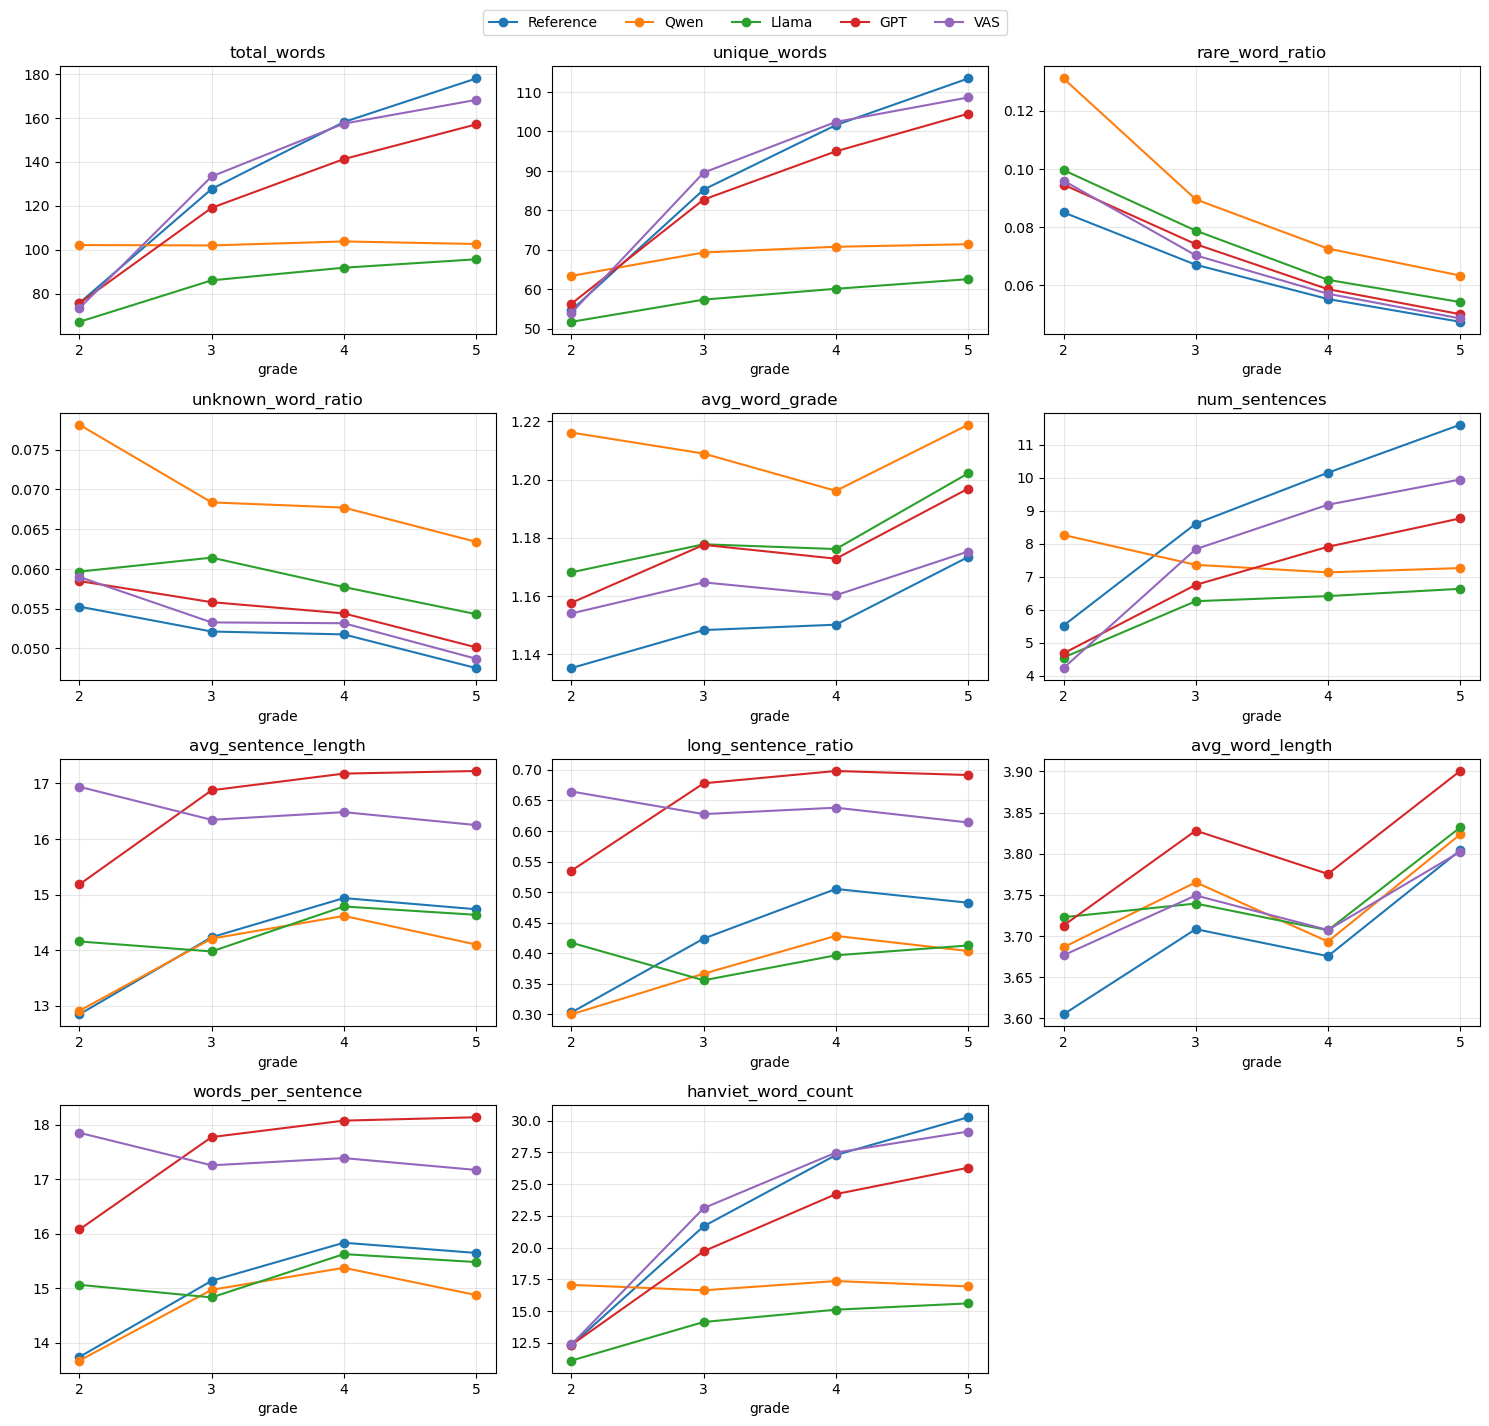

In [1]:
import pandas as pd

df1 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_ref.xlsx")
df2 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_qwen.xlsx")
df3 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_llama.xlsx")
df4 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_gpt.xlsx")
df5 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\abs\datatest_main_score_dif_mymodel.xlsx")

cols = ["total_words", "unique_words", "rare_word_ratio", "unknown_word_ratio",
        "avg_word_grade", "num_sentences", "avg_sentence_length",
        "long_sentence_ratio", "avg_word_length", "words_per_sentence",
        "hanviet_word_count"]


import matplotlib.pyplot as plt
import numpy as np

model_names = {"df1": "Reference", "df2": "Qwen", "df3": "Llama", "df4": "GPT", "df5": "VAS"}
dfs = {"df1": df1, "df2": df2, "df3": df3, "df4": df4, "df5": df5}
grades = [2, 3, 4, 5]

records = []
for key, df in dfs.items():
    for g in grades:
        m = df.loc[df["grade"] == g, cols].mean()
        m["model"] = model_names[key]
        m["grade"] = g
        records.append(m)
summary = pd.DataFrame(records)
summary

n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    for name in model_names.values():
        sub = summary[summary["model"] == name].sort_values("grade")
        ax.plot(sub["grade"], sub[col], marker="o", label=name)
    ax.set_title(col)
    ax.set_xlabel("grade")
    ax.set_xticks(grades)
    ax.grid(True, alpha=0.3)

for j in range(n, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

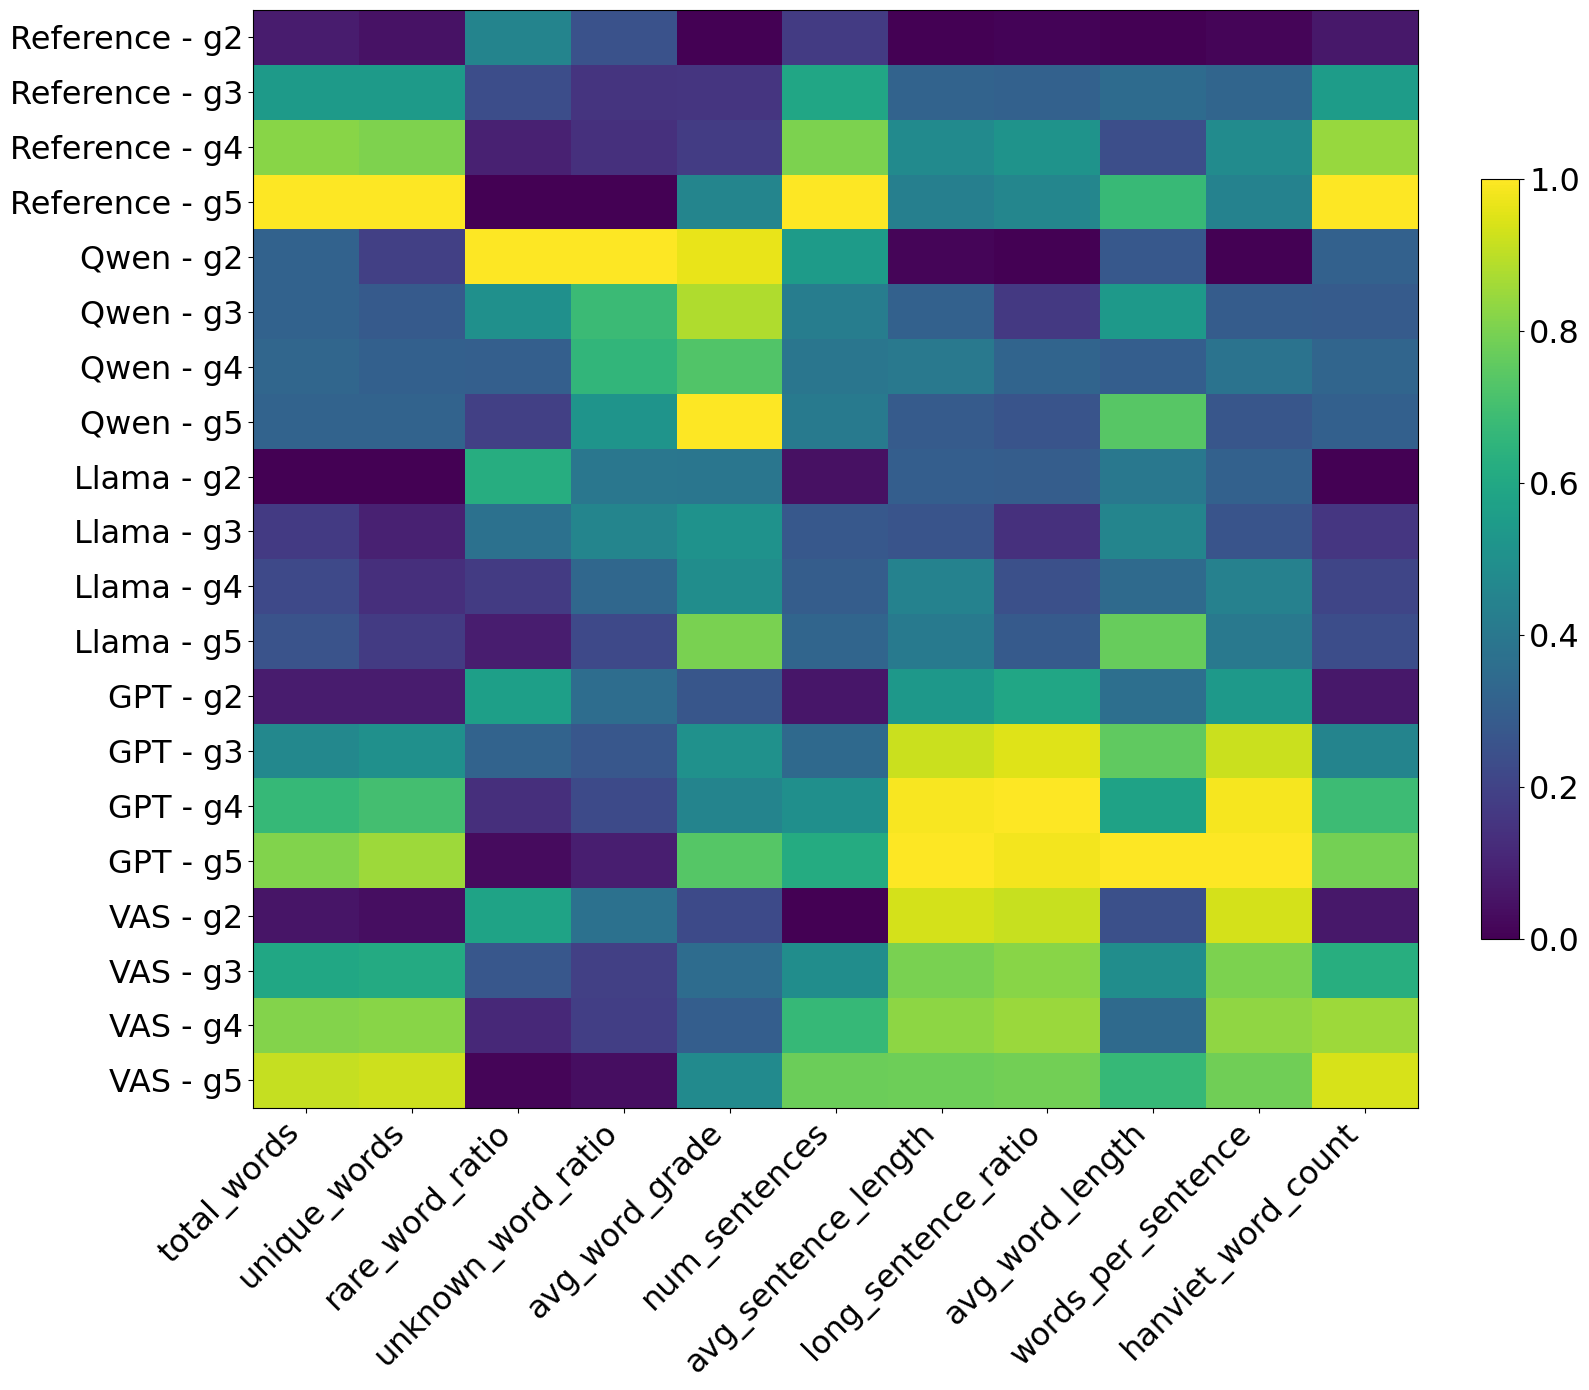

In [2]:
norm = summary.copy()
norm[cols] = (norm[cols] - norm[cols].min()) / (norm[cols].max() - norm[cols].min())
norm["label"] = norm["model"] + " - g" + norm["grade"].astype(str)

mat = norm.set_index("label")[cols]
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(mat.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=23)
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index, fontsize=23)
cbar = fig.colorbar(im, ax=ax, fraction=0.03)
cbar.ax.tick_params(labelsize=23)
plt.tight_layout()
plt.show()

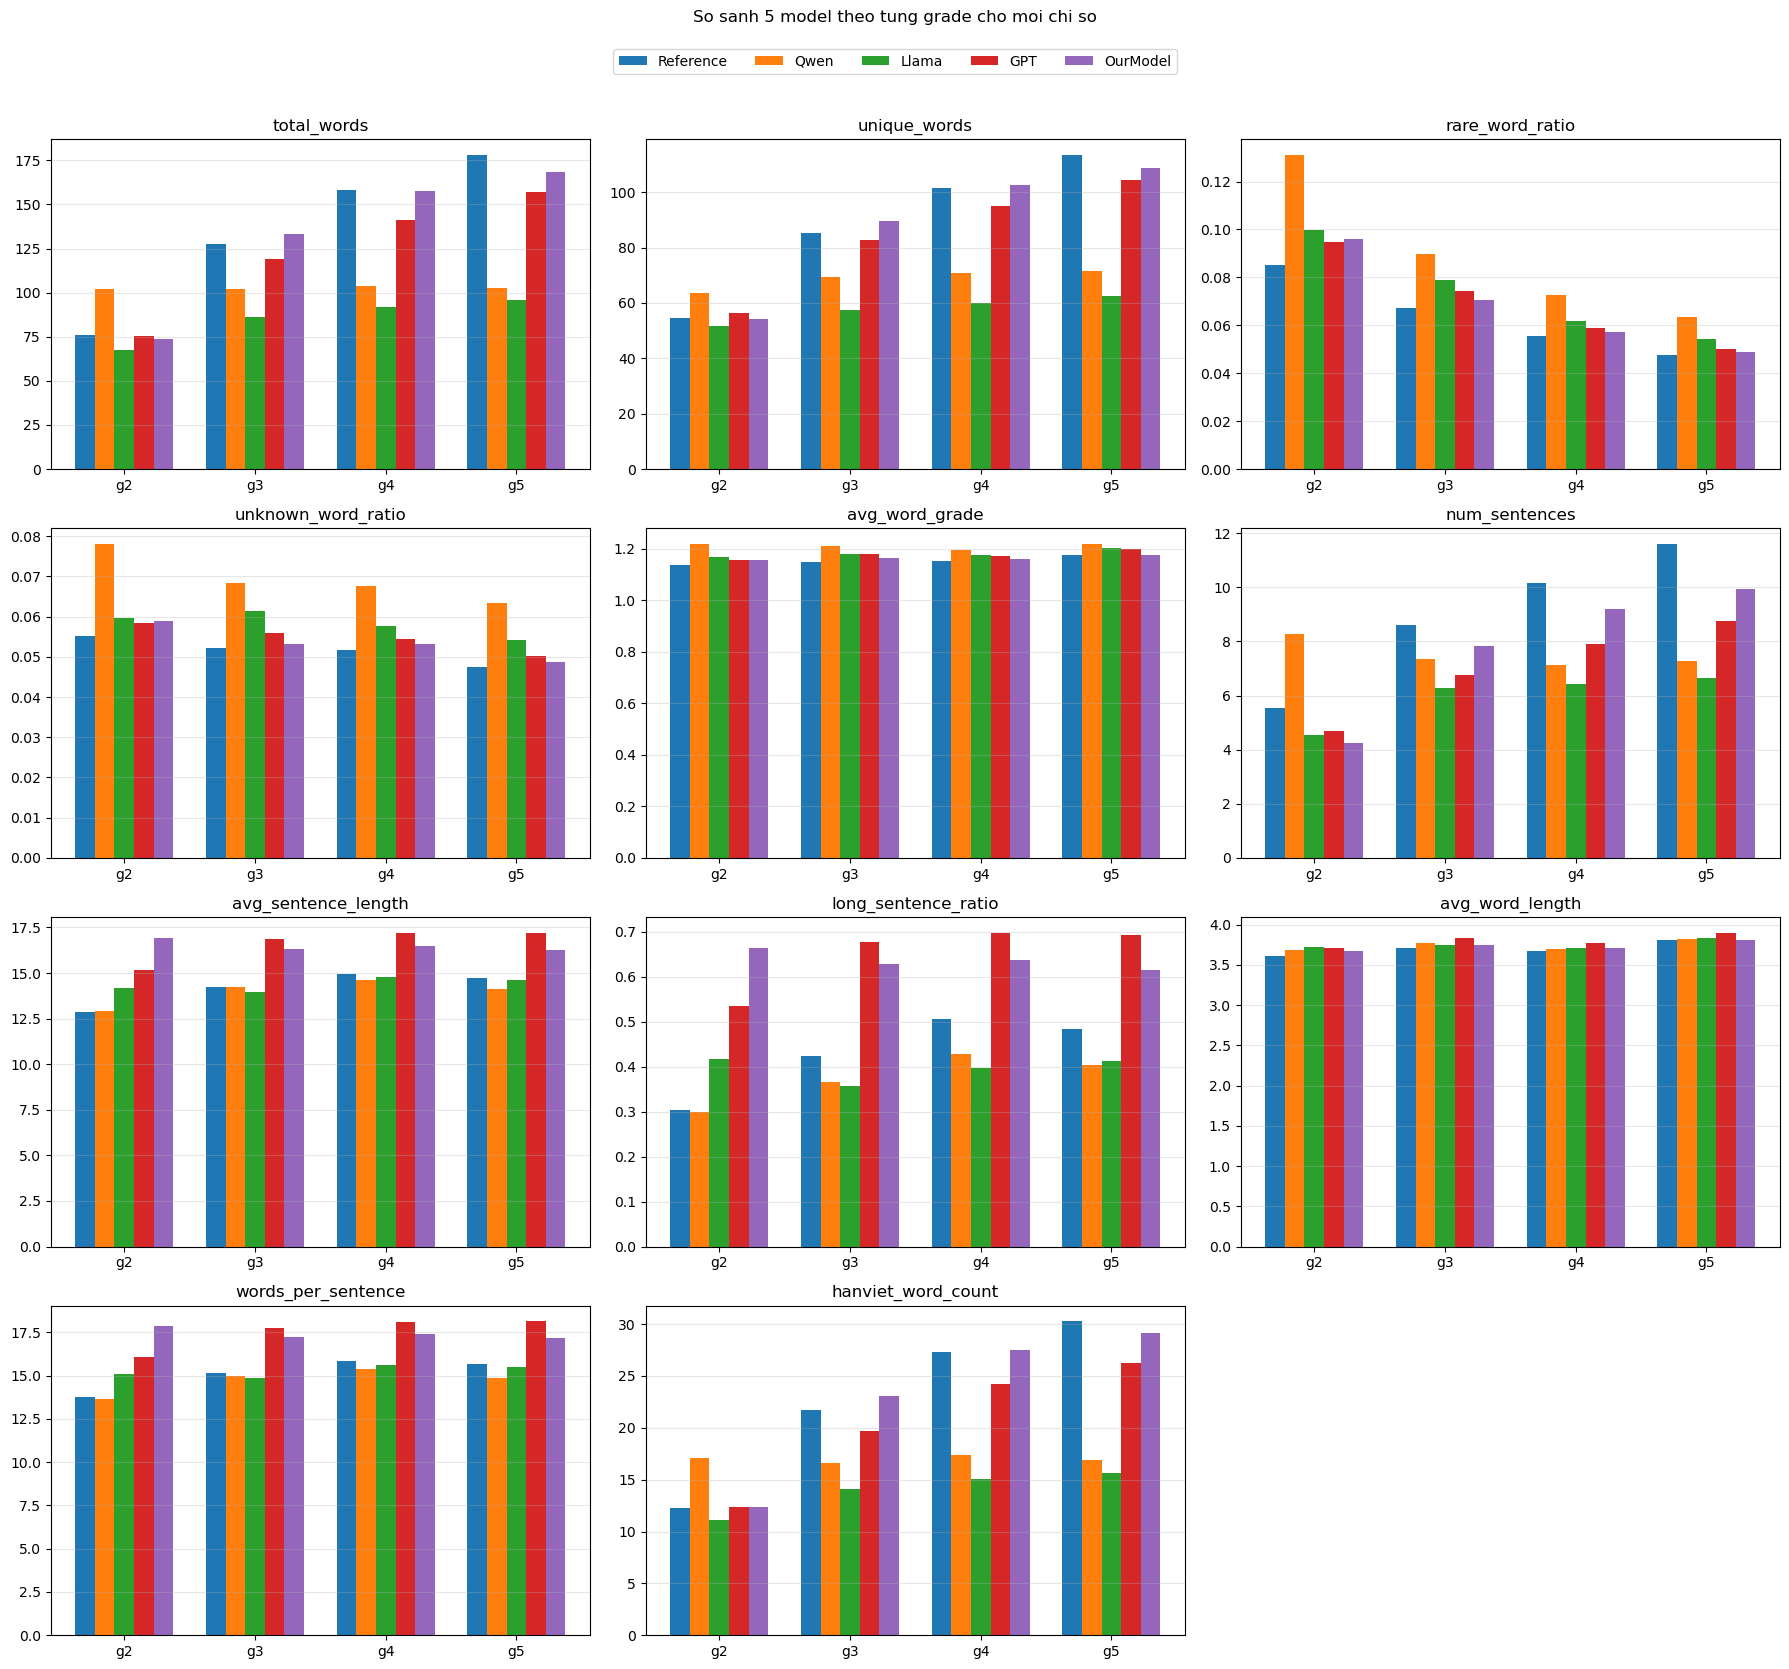

In [7]:
names = list(model_names.values())
x = np.arange(len(grades))
width = 0.15

n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    for k, name in enumerate(names):
        sub = summary[summary["model"] == name].sort_values("grade")
        ax.bar(x + (k - 2) * width, sub[col].values, width, label=name)
    ax.set_title(col)
    ax.set_xticks(x)
    ax.set_xticklabels([f"g{g}" for g in grades])
    ax.grid(True, axis="y", alpha=0.3)

for j in range(n, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("So sanh 5 model theo tung grade cho moi chi so", y=1.04)
plt.tight_layout()
plt.show()

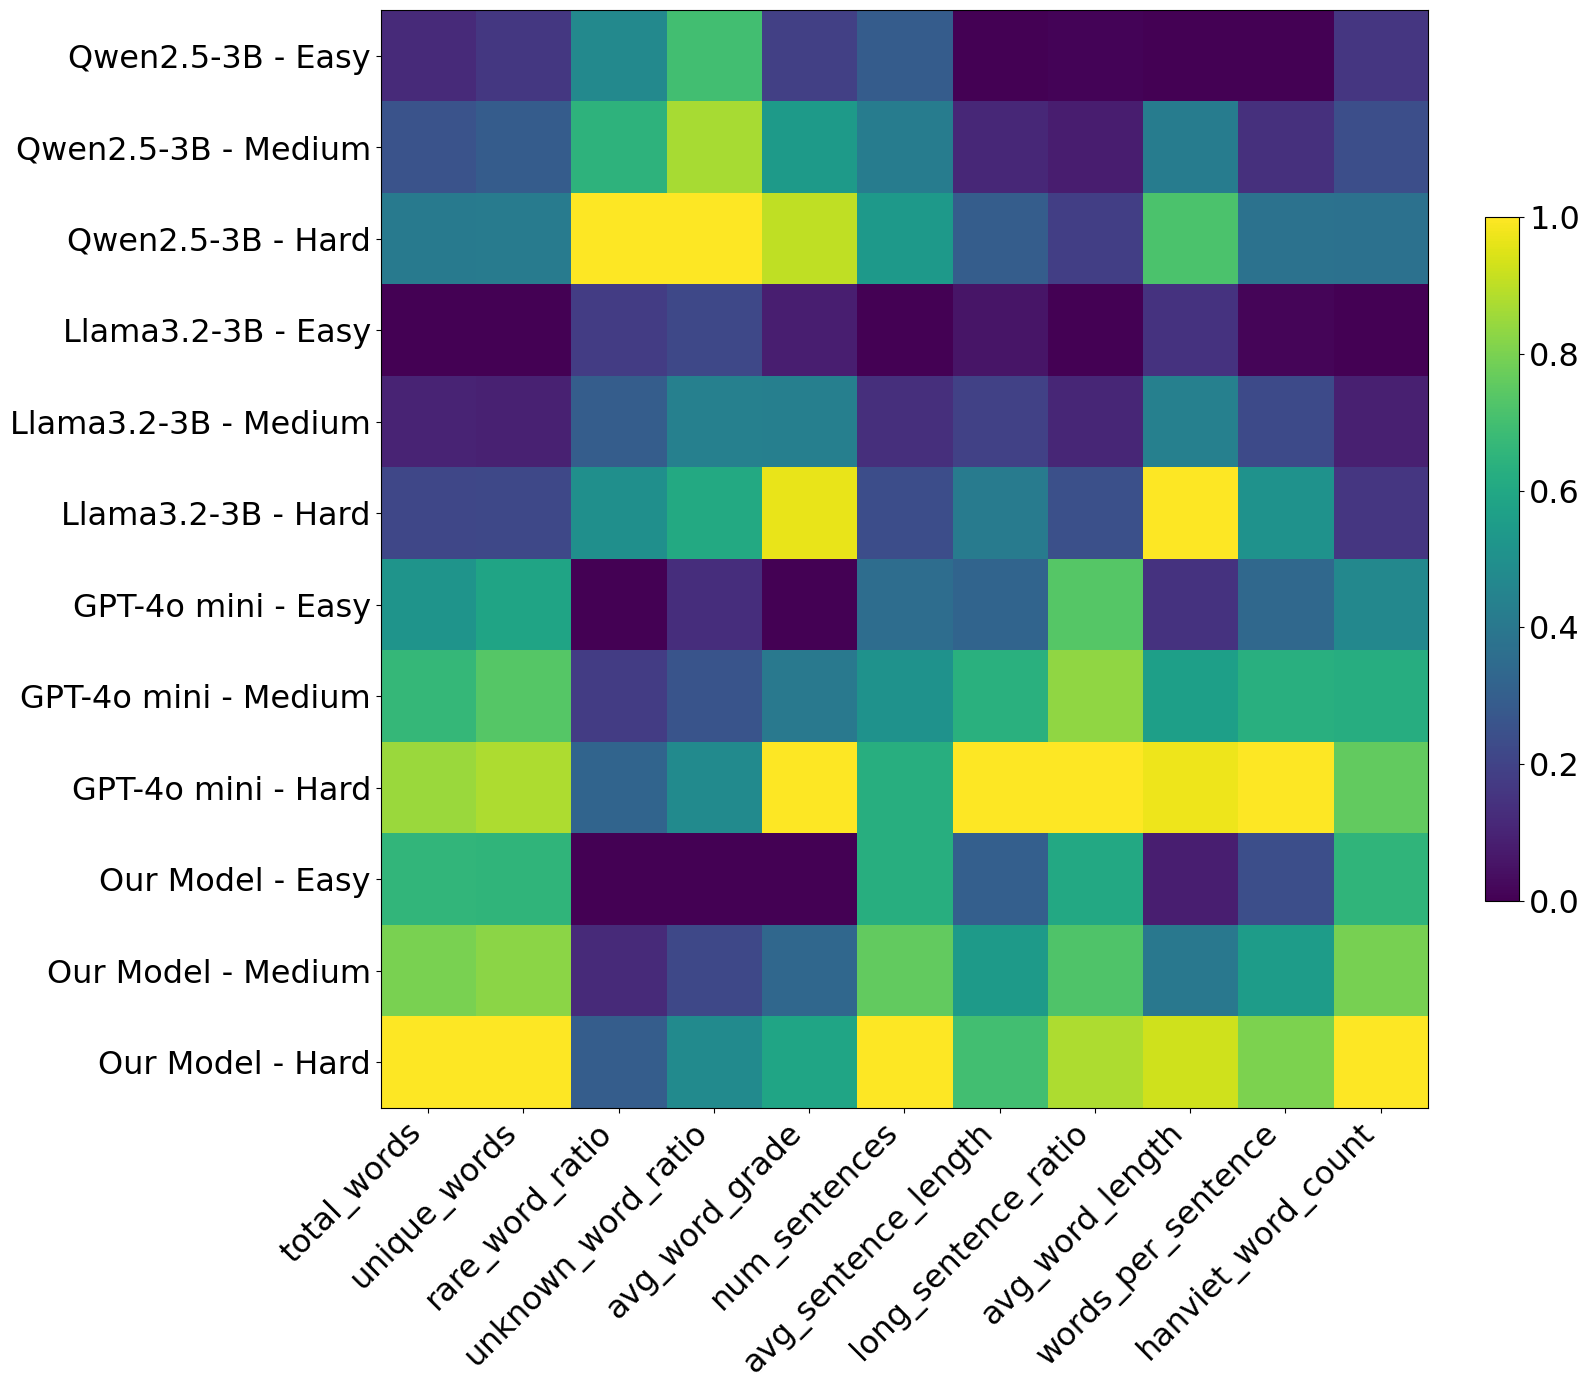

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_summary.xlsx")
df
mat_raw = df.copy()
if isinstance(mat_raw.columns, pd.MultiIndex):
    mat_raw.columns = [
        f"{a} ({b})" if not str(a).startswith("Unnamed") else str(b)
        for a, b in mat_raw.columns
    ]
mat_raw = mat_raw.set_index(mat_raw.columns[0])
mat_raw = mat_raw.apply(pd.to_numeric, errors="coerce")

mat_t = mat_raw.T
norm = (mat_t - mat_t.min()) / (mat_t.max() - mat_t.min())
norm.index = [str(i).replace(" (Mean-", " - ").rstrip(")") for i in norm.index]

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(norm.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(norm.columns)))
ax.set_xticklabels(norm.columns, rotation=45, ha="right", fontsize=23)
ax.set_yticks(range(len(norm.index)))
ax.set_yticklabels(norm.index, fontsize=23)
cbar = fig.colorbar(im, ax=ax, fraction=0.03)
cbar.ax.tick_params(labelsize=23)
plt.tight_layout()
plt.show()